# Trabajo Fin de Máster  
### Inteligencia artificial explicable para el estudio de la fragmentación urbana  
#### Análisis comparativo del rendimiento y la interpretabilidad de modelos de aprendizaje supervisado para la clasificación de patrones de cerramiento residencial

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis de interpretabilidad global

### 📝 Descripción del notebook
En este notebook se presenta el estudio de interpretabilidad de los modelos evaluados en el experimento. Para los modelos transparentes se emplean los mecanismos de explicabilidad intrínsecos de cada algoritmo, mientras que los modelos de caja negra se analizan mediante la técnica de explicabilidad *post-hoc* *SHAP*. En todos los modelos se realiza un análisis de la importancia global de las variables predictoras para identificar cuáles tienen mayor influencia en la clasificación, así como un análisis específico de cada grado de cerramiento para caracterizarlo urbanísticamente a partir de las variables más relevantes para su predicción. Este estudio permite evaluar tanto la coherencia de los patrones aprendidos por los modelos con el conocimiento del dominio como la capacidad de los distintos mecanismos de interpretabilidad para proporcionar explicaciones comprensibles y útiles.

Para realizar este análisis se ha seguido la metodología descrita en el *notebook* [4.1_Global_interp_methodology.ipynb](4.1_Global_interp_methodology.ipynb). De acuerdo con ella, todos los modelos se han optimizado sobre el conjunto completo de datos utilizando el mismo espacio de búsqueda de hiperparámetros definido para el protocolo experimental de evaluación del rendimiento. Los modelos entrenados se han serializado mediante la librería *pickle* y almacenado en archivos con extensión *.pkl* en el directorio *output/models*.

### Indice de contenidos
1. [Regresión logística multinomial](#regresion_logistica)
    * [1.1 Importancia global de variables](#reg_global)
    * [1.2 Caracterización del grado de cerramiento](#reg_cerramiento)

2. [Árbol de decisión](#arbol)
    * [2.1 Importancia global de variables](#arbol_glob)
    * [2.2 Caracterización del grado de cerramiento](#arbol_cerramiento)

3. [Modelos de caja negra](#caja_negra)
    * [3.1 Importancia global de variables](#caja_negra_glob)
    * [3.2 Caracterización del grado de cerramiento](#caja_negra_cerramiento)

# Configuración de entorno e *imports*

Este proyecto ha sido realizado en un entorno Anaconda con la versión 3.11.15 de *Python*. Las versiones de las librerias requeridas se encuentran en el fichero *requirements-full.txt*.

En esta sección se importan las librerias necesarias para la ejecución de este fichero *jupyter notebook*, se activa el *reload* de módulos externos y se configuran aspectos globales y de reproducibilidad.

In [1]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration object
from src.config import cfg

# XAI visualization methods
from src.XAI_utils import (
    # MULTINOMIAL LOGISTIC REGRESSION METHODS
    load_lr_coefs,
    plot_lr_feature_importance,
    plot_lr_class_coefs,
    
    # DECISION TREE METHODS
    plot_tree_feature_importance,
    get_visual_decision_tree,
    get_leaf_classes_distribution,
    
    # SHAP
    get_shap_svm,
    get_shap_tree,
    plot_shap_global_feature_importance,
    plot_shap_heatmap,
    plot_shap_class_dashboard
)

**Solución a problemas en *imports***

Si los *imports* del módulo `src` fallan al ejecutar este cuaderno en un entorno diferente, descomente y ejecute la siguiente celda:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [4]:
# Set models folder
models_folder = os.path.join(cfg.OUTPUT_DIR, "models")

In [5]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

<a id="regresion_logistica"></a>
# 1. Regresión logística multinomial

La interpretabilidad global de la regresión logística multinomial se basa en el análisis de sus coeficientes, que constituye el mecanismo de explicabilidad intrínseca del modelo.

Dada la naturaleza multiclase del conjunto de datos, el modelo estima un coeficiente para cada combinación de variable predictora y clase de la variable objetivo. Estos coeficientes se analizan desde dos perspectivas complementarias: de forma agregada para identificar la importancia global de las variables y de forma desagregada para caracterizar la contribución de cada variable a los distintos grados de cerramiento.

Se utiliza el modelo entrenado con el estimador *LogisticRegression* sobre todos los datos disponibles, que ha sido almacenado en *output/models/Logistic_Regression_model.pkl*. Este estimador almacena una matriz con los coficientes $\beta$ aprendidos por el modelo, de dimensiones $K \times M$ donde $K$ es el número de clases y $M$ el número de características o variables predictoras. En este problema, la matriz de coeficientes presenta dimensiones $[5,25]$, donde cada fila corresponde a cada uno de los cinco grados de cerramiento y cada columna representa una de las $25$ variables predictoras.

A continuación se carga la matriz de coeficientes del modelo.

In [6]:
# Set PKL file path and load the coeff matrix
LR_artifact_path =  os.path.join(models_folder,"Logistic_Regression_model.pkl")
LR_coef_df, LR_odds_df = load_lr_coefs(cfg, LR_artifact_path)
LR_coef_df

Logistic_Regression model successfully loaded from pkl file.
Coefficient matrix shape: (5, 25)


,CSS,CFS,CPE,LIN,LEX,DIS_1,DIS_2,DIS_3,VER,MUR,CAD,BOL,ARB,CPP,PVI,PBL,COM,COMS,PPU,PRE,PPR,GSE,CSE,BSE,ASE
Protegido,-2.620734,0.789259,-0.862114,-3.430467,-0.376423,-0.508542,-0.906209,1.155353,1.097056,-0.103533,-0.001543,0.138102,-0.738445,-1.049072,-3.978736,-6.309256,2.012325,1.324107,-4.110672,-0.284909,1.356499,1.669723,5.916887,2.567041,3.495756
Controlado,-1.276828,-0.988926,-0.308364,-3.095256,0.461351,-0.753318,-0.354230,1.455859,0.613997,1.549509,-0.261263,-0.733050,-0.138638,-0.284452,-3.367413,-0.763908,-0.178030,-0.657614,-1.984175,0.187643,-0.159928,-2.849423,-1.045214,0.593155,-1.561504
Autoaislado,5.100228,3.255703,2.476314,3.834809,0.438360,2.287055,2.983976,-5.969160,-0.508291,-0.303293,-0.008745,1.036344,0.019459,0.935249,1.171900,0.272633,0.236492,0.306366,4.774024,0.617170,2.229660,-0.745297,0.024166,-2.353654,-0.073399
Individualista,-1.126011,-0.726645,-0.252357,-1.202397,-0.872869,0.066560,-1.222180,1.301899,-0.357498,0.078146,0.387487,-0.665895,0.274038,0.747666,5.622134,6.897512,-0.487568,-0.477600,-2.524407,-0.312463,-0.324023,-0.148753,-5.014666,-0.546143,-0.840067
Simbólico,-0.076655,-2.329391,-1.053479,3.893311,0.349581,-1.091755,-0.501357,2.056049,-0.845263,-1.220829,-0.115936,0.224498,0.583586,-0.349391,0.552116,-0.096982,-1.583219,-0.495260,3.845230,-0.207442,-3.102208,2.073749,0.118828,-0.260399,-1.020786


<a id="reg_global"></a>
## 1.1 Importancia global de variables

La importancia global de cada variable se cuantifica mediante la media del valor absoluto de sus coeficientes $\beta$ a través de las cinco clases. Esta medida resume la influencia global de cada variable sobre las predicciones del modelo, de forma que aquellas con un mayor coeficiente medio absoluto se consideran las más relevantes.

La siguiente figura representa esta medida mediante un gráfico de barras, ordenando las variables de mayor a menor importancia.

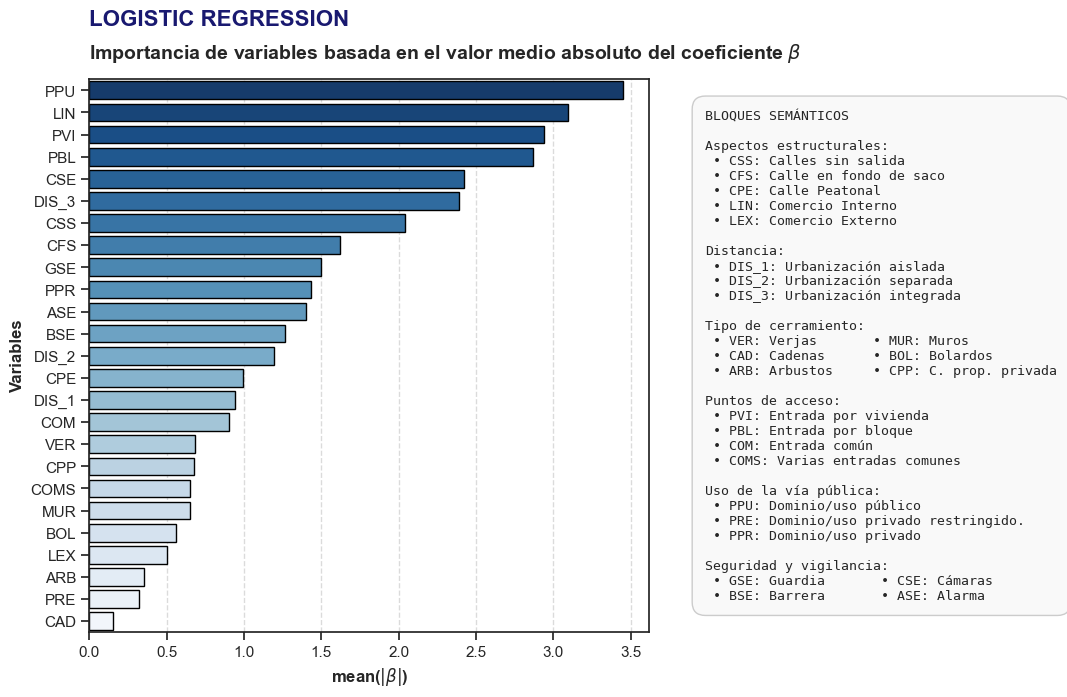

In [7]:
plot_lr_feature_importance(LR_coef_df, criterion="mean", figsize=[14, 7])

Se observa que las características más influyentes pertenecen a distintos bloques semánticos. La variable con mayor importancia para el modelo es el *uso y dominio público de la vía (PPU)* que pertenece al bloque semántico de ``*Uso de la vía pública*''. El *uso y dominio privado (PPR)* alcanza aproximadamente la mitad de la importancia de *PPU*, mientras que el *uso privado con acceso público restringido (PRE)* apenas influye al presentar un coeficiente medio próximo a cero. Este comportamiento indica que el modelo discrimina principalmente entre configuraciones con un carácter claramente público o claramente privado, mientras que la configuración intermedia aporta escasa capacidad discriminativa.

El bloque de ``*Aspectos estructurales*'' está liderado por la variable de *comercios internos (LIN)*, que constituye la segunda característica más relevante del modelo, seguida por las calles disuasorias (*CSS* y *CFS*), con coeficientes más reducidos. En contraste, las *calles peatonales (CPE)* y los *comercios externos (LEX)* presentan una importancia considerablemente menor. Este resultado sugiere que el modelo encuentra mayor capacidad discriminativa en aquellos elementos estructurales asociados al aislamiento del complejo residencial que en aquellos que favorecen su integración con el entorno urbano.

En el bloque de ``*Puntos de acceso*'', la *entrada por vivienda (PVI)* y la *entrada por bloque (PBL)* destacan claramente sobre los accesos comunes (*COM* y *COMS*), cuya contribución es considerablemente menor. Esto indica que la presencia o ausencia de accesos individuales desempeña un papel más relevante en la clasificación que la presencia o ausencia de accesos comunes.

El bloque de ``*Seguridad y vigilancia*'' concentra el mayor número de variables con coeficientes medios elevados. Aunque las *cámaras de seguridad (CSE)* constituyen la característica más influyente del bloque, el resto de elementos de seguridad (*GSE*, *ASE* y *BSE*) también presentan contribuciones relevantes. Este resultado indica que el modelo caracteriza la seguridad como un concepto multidimensional, en el que distintos mecanismos de vigilancia aportan información complementaria para discriminar entre los grados de cerramiento.

En el bloque de ``*Distancia*'' destaca la dominancia de *DIS_3* frente a *DIS_1* y *DIS_2*. Esto debe interpretarse teniendo en cuenta que estas variables representan categorías mutuamente excluyentes de una misma variable categórica. Por tanto, la contribución de cada categoría no debe analizarse de forma independiente, ya que la presencia de una de ellas implica necesariamente la ausencia del resto.

Finalmente, uno de los resultados más llamativos del análisis es la escasa importancia de las variables pertenecientes al bloque ``Tipo de cerramiento'', cuyos coeficientes medios se sitúan en la parte baja del ranking. Desde una perspectiva urbanística, cabría esperar que estas características tuvieran una influencia más directa sobre la clasificación del grado de cerramiento. Sin embargo, el modelo se apoya preferentemente en variables asociadas a la forma de acceso, seguridad, elementos viarios y tipo de uso de los mismos.

<a id="reg_cerramiento"></a>
## 1.2 Caracterización del grado de cerramiento

La caracterización de los grados de cerramiento se realiza mediante el análisis del signo y la magnitud de los coeficientes asociados a cada clase. Los coeficientes $\beta$ determinan la contribución de la variable al *log-odd* de cada clase y, por tanto, su efecto sobre la probabilidad de pertenencia a dicha clase. De esta forma, las variables pueden interpretarse como factores urbanísticos catalizadores o inhibidores de un determinado grado de cerramiento.

Para realizar este estudio se ha desarrollado una visualización que representa los coeficientes $\beta$ asociados a cada variable predictora mediante un gráfico de barras horizontal. Las variables se agrupan de acuerdo a los bloques semánticos y, dentro de cada bloque, se ordenan según la magnitud absoluta de su coeficiente.

El signo del coeficiente se representa mediante una escala de color que transita desde azul para valores negativos hasta rojo para valores positivos, facilitando la identificación visual de factores inhibidores y catalizadores. Para garantizar una comparación consistente entre grados de cerramiento, el eje de abscisas correspondiente al valor del coeficiente $\beta$ se mantiene fijo en todas las representaciones y se define a partir del rango global de coeficientes obtenido considerando todas las clases.

Esta visualización se obtiene mediante la función *plot_lr_class_coefs()*.

**Grado de cerramiento *Protegido***

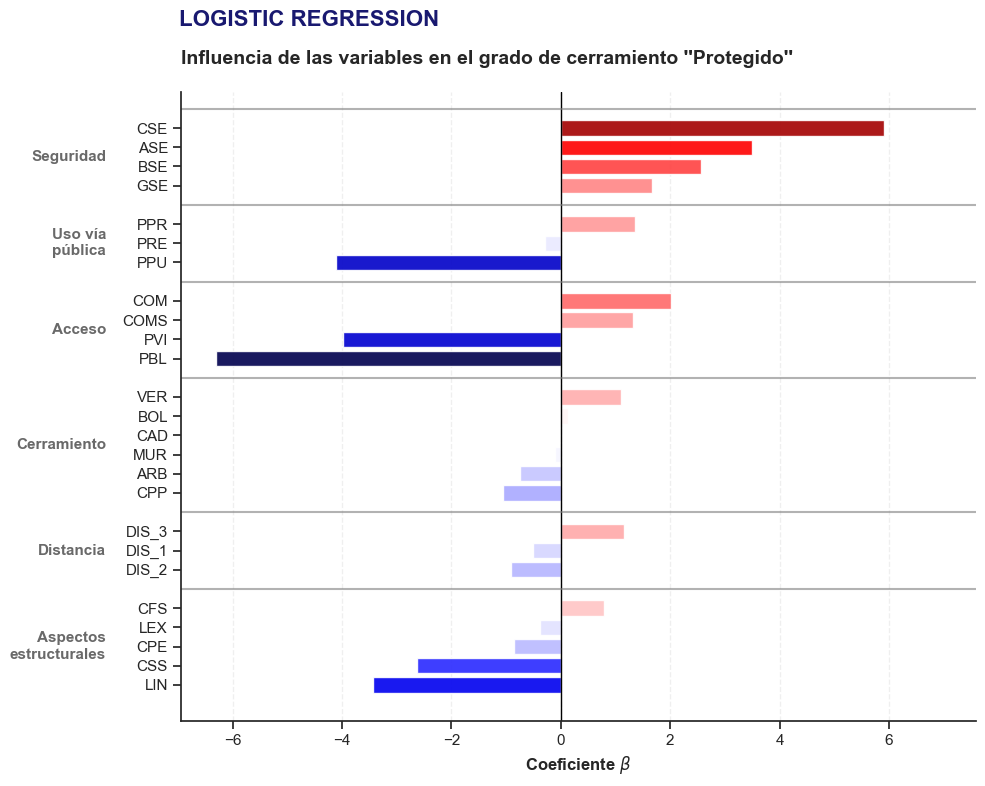

In [8]:
plot_lr_class_coefs(LR_coef_df, "Protegido")

El perfil aprendido por el modelo para identificar la categoría *Protegido*, de acuerdo al gráfico de barras, está dominado por las variables del bloque ``*Seguridad y vigilancia*''. La presencia de estos elementos incrementa la probabilidad de pertenencia a esta categoría, destacando especialmente las *cámaras de seguridad (CSE)* como el principal factor catalizador.

Los factores inhibidores se distribuyen entre distintos bloques semánticos. Destacan la *entrada por bloque (PBL)*, la *entrada por vivienda (PVI)* y el *uso público de la vía (PPU)*. En consecuencia, los accesos comunes (*COM* y *COMS*) y el *dominio y uso privado de la vía (PPR)* actúan como factores catalizadores, con una magnitud inferior a las variables del bloque ``*Seguridad y vigilancia*''. En menor medida, determinados elementos estructurales internos, como las *calles sin salida (CSS)* y los *comercios internos (LIN)*, también contribuyen a reducir la probabilidad de pertenencia a esta categoría.

Puede interpretarse que el modelo caracteriza el grado de cerramiento *Protegido* como una tipología que restringe de forma significativa el acceso de personas no residentes. Esta configuración se refleja en la ausencia de comercios internos, el predominio del uso privado de la vía pública y la presencia de accesos comunes controlados por servicios de seguridad, frente a accesos directos por vivienda o por bloque. En conjunto, estas características reducen la permeabilidad del espacio y dificultan el tránsito de personas externas al complejo residencial.

**Grado de cerramiento *Controlado***

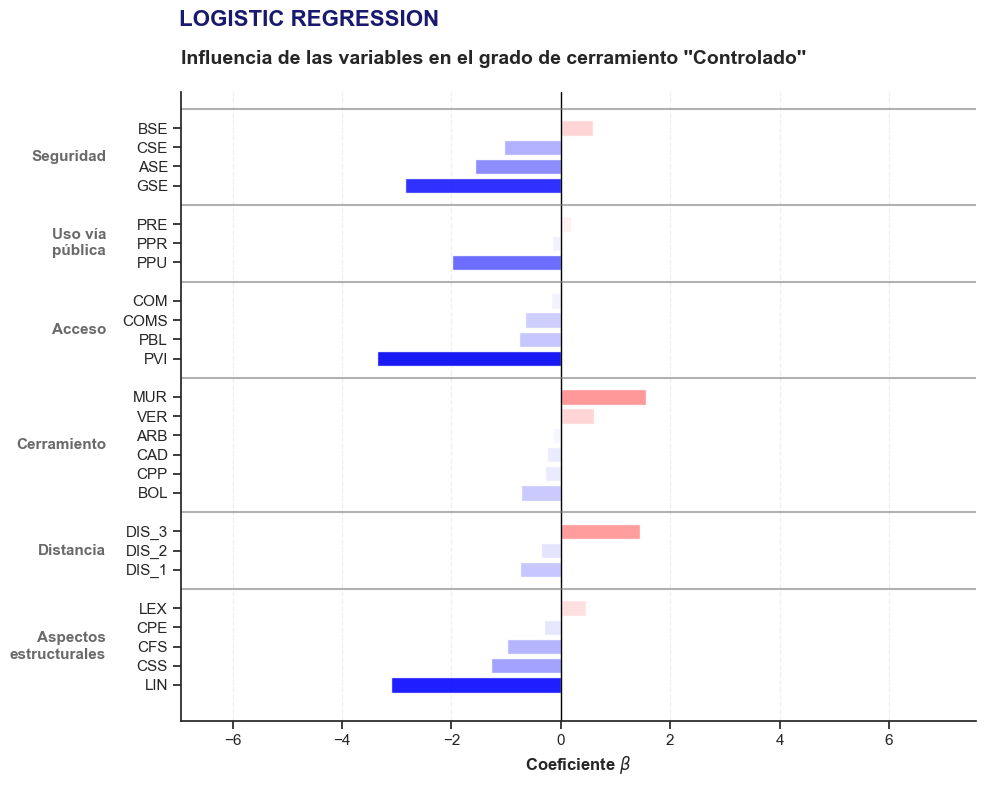

In [9]:
plot_lr_class_coefs(LR_coef_df, "Controlado")

El perfil aprendido por el modelo para la categoría *Controlado*, de acuerdo al valor de los coeficientes $\beta$, se caracteriza principalmente por la contribución de factores inhibidores, ya que los coeficientes de mayor magnitud absoluta presentan signo negativo. En particular, la presencia de *comercios internos (LIN)*, *entrada por vivienda (PVI)*, *uso público de la vía (PPU)* y *cámaras de seguridad (CSE)* reduce la probabilidad de pertenencia a este grado de cerramiento.

Este patrón presenta similitudes con el grado de cerramiento *Protegido*, donde las características asociadas a una mayor apertura del complejo residencial también actúan como factores inhibidores. Sin embargo, ambas categorías se diferencian principalmente por el papel del bloque ``*Seguridad y vigilancia*'': mientras que la presencia de estos elementos favorece la clasificación como *Protegido*, en el grado de cerramiento *Controlado* funcionan como factor inhibidor.

Este análisis permite caracterizar el grado de cerramiento *Controlado* como una tipología cuya configuración dificulta el tránsito de personas no residentes, pero que no incorpora mecanismos de seguridad o vigilancia para restringir el acceso, lo que reduce la intensidad del cerramiento percibido.

**Grado de cerramiento *Autoaislado***

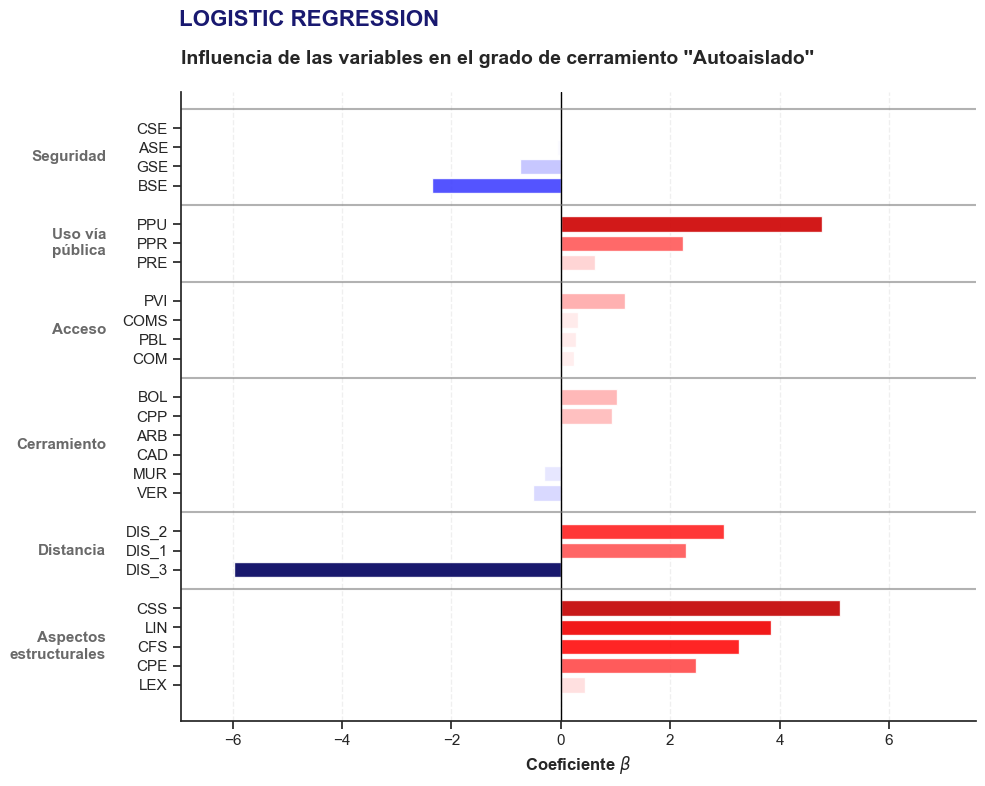

In [10]:
plot_lr_class_coefs(LR_coef_df, "Autoaislado")

En la figura se observa que la categoría *Autoaislado* se caracteriza por un patrón compuesto principalmente por factores catalizadores asociados a la estructura interna del complejo residencial y por una variable claramente inhibidora que específica su localización.

El bloque semántico de ``*Aspectos estructurales*'' constituye el principal conjunto de factores catalizadores. La presencia de elementos viarios internos, como las *calles sin salida (CSS)*, las *calles en fondo de saco (CFS)* y las *calles peatonales (CPE)*, junto con la existencia de *comercios internos (LIN)*, favorece la clasificación de un complejo residencial como *Autoaislado*.

El principal factor inhibidor es la variable *DIS_3*, que indica la integración del complejo residencial en el núcleo urbano. Esta variable presenta un coeficiente negativo de elevada magnitud, coherente con el análisis exploratorio de la Sección correspondiente, donde no se identifica ningún complejo residencial clasificado como *Autoaislado* con esta situación geográfica. En consecuencia, las categorías alternativas (*DIS_1* y *DIS_2*), que indican que el complejo residencial esta aislado y separado del núcleo urbano respectivamente, actúan como factores catalizadores de este grado de cerramiento.

Respecto al bloque de ``*Uso de la vía pública*'', tanto el uso público (*PPU*) como el uso privado (*PPR*) presentan contribuciones positivas. Este comportamiento indica que, para el grado de cerramiento *Autoaislado*, el tipo de dominio de la vía no constituye un factor determinante, sino que es la presencia de una estructura viaria interna, independientemente de su régimen de uso, la característica urbanística asociada a esta categoría.

En conjunto, el modelo caracteriza el grado de cerramiento *Autoaislado* como un tipo de complejo residencial localizado fuera del núcleo urbano y definido por una estructura espacial propia, con presencia de elementos viarios internos como calles disuasorias y peatonales.

**Grado de cerramiento *Individualista***

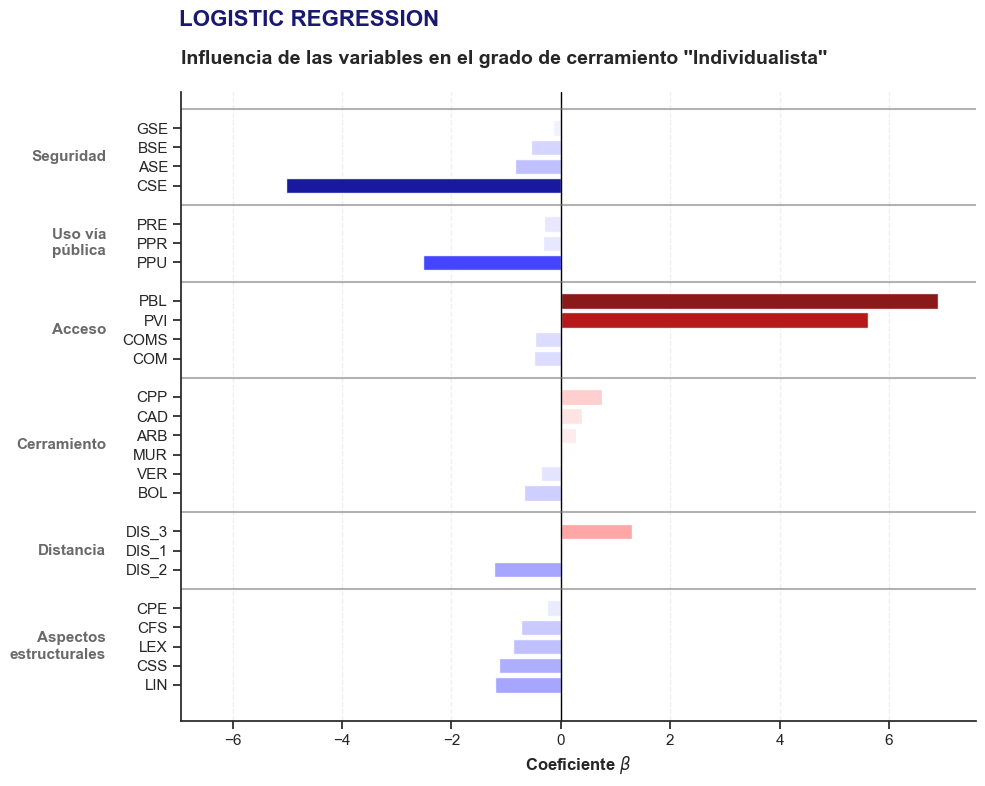

In [11]:
plot_lr_class_coefs(LR_coef_df, "Individualista")

En la figura se observa que la categoría *Individualista* presenta un perfil definido por un conjunto reducido de variables con una contribución claramente diferenciada respecto al resto. Los principales factores catalizadores son la *entrada por bloque (PBL)* y por *vivienda (PVI)*, mientras que la presencia de *cámaras de seguridad (CSE)* constituye el principal factor inhibidor.

Tanto las variables del bloque de "*uso de la vía pública*" como del bloque de `*aspectos estructurales*'' presentan coeficientes negativos lo que sugiere que los complejos residenciales *Individualistas* tienden a presentar una escasa o nula estructura viaria interna, lo que se traduce, en una ausencia de usos asociados a dicha red viaria.

Se concluye que el modelo caracteriza el grado de cerramiento *Individualista* como una tipología en la que los accesos a las zonas comunes son individuales y no existen mecanismos de seguridad o control en dichos accesos. Esta configuración favorece la permeabilidad del entorno inmediato al complejo residencial reduciendo la intensidad de cerramiento.

**Grado de cerramiento *Simbólico***

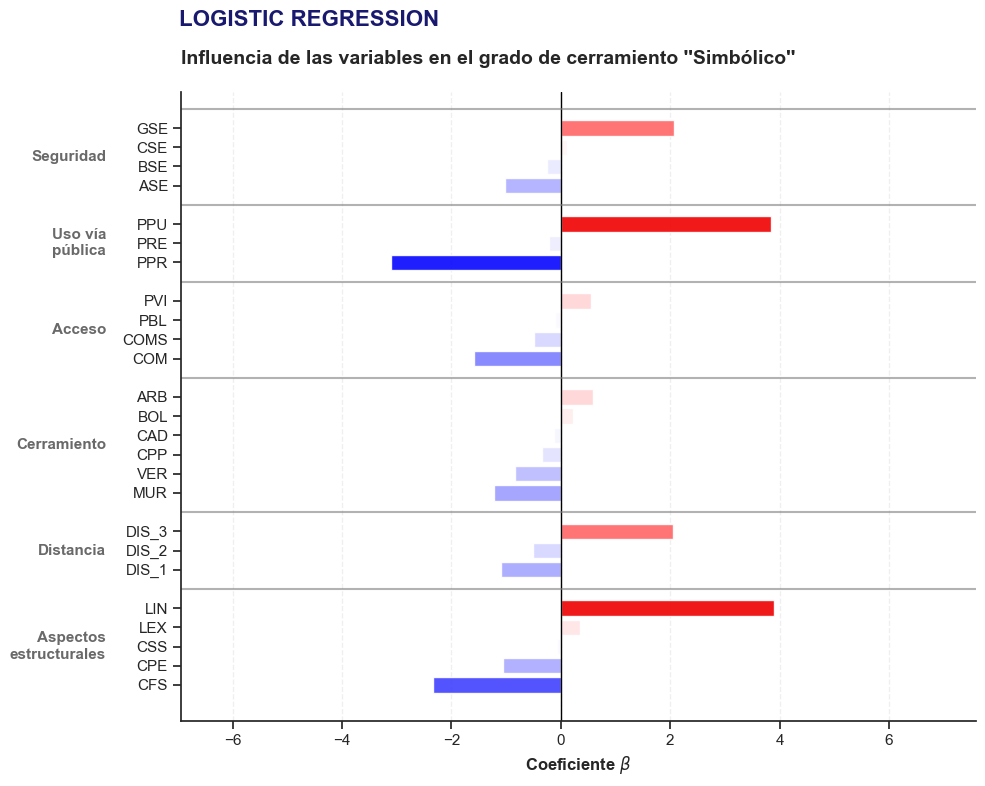

In [12]:
plot_lr_class_coefs(LR_coef_df, "Simbólico")

El perfil aprendido por el modelo para la categoría *Simbólico*, de acuerdo al gráfico, está dominado por las variables del bloque ``*Uso de la vía pública*''. En particular, el *dominio y uso público de la vía (PPU)* actúa como el principal factor catalizador, mientras que el *uso privado de la vía (PPR)* presenta un efecto inhibidor de magnitud similar. Este comportamiento indica que la configuración del espacio viario constituye uno de los principales elementos discriminativos para identificar esta categoría. Además, la presencia de *comercios internos (LIN)* y la integración del complejo residencial en el núcleo urbano (*DIS_3*) contribuyen positivamente a su clasificación, en concordancia con la interpretación urbanística asociada a un grado de cerramiento de menor intensidad.

Destaca que la presencia de *guardias de seguridad (GSE)* contribuya de forma positiva a la probabilidad de pertenencia al grado de cerramiento *Simbólico*, lo cual no resulta coherente con un nivel de cerramiento sutil o inexistente. No obstante, este resultado debe interpretarse con cautela, ya que este grado de cerramiento presenta una baja precisión de clasificación en el modelo de regresión logística. Por tanto, los coeficientes asociados a esta categoría pueden estar reflejando patrones influenciados por predicciones menos fiables o por características compartidas con otras categorías.

Puede concluirse que el modelo caracteriza el grado de cerramiento *Simbólico* como aquellos complejos residenciales que cuentan con elementos que favorecen el tránsito de no residentes y que por tanto diluyen la intensidad de cerramiento percibida, como la presencia de comercios internos, el uso público de la vía o la integración en el tejido urbano.

<a id="arbol"></a>
# 2. Árbol de decisión

La interpretabilidad del árbol de decisión se aborda mediante los mecanismos de explicabilidad intrínseca al propio modelo: la reducción de impureza y las reglas de decisión . En primer lugar, se analiza la importancia global de las variables utilizando la reducción de impureza como medida de relevancia. En segundo lugar, se estudian las reglas de decisión aprendidas por el modelo para caracterizar cada uno de los grados de cerramiento.

Se utiliza el modelo entrenado con el estimador *DecisionTreeClassifier* sobre todos los datos disponibles, que ha sido almacenado en *output/models/Decision_Tree_model.pkl*.

In [13]:
# Set pkl file path
DT_artifact_path =  os.path.join(models_folder,"Decision_Tree_model.pkl")

<a id="arbol_glob"></a>
## 2.1 Importancia global de variables

La medida de impureza seleccionada como resultado del proceso de optimización de hiperparámetros ha sido el criterio de entropía.

La siguiente figura representa la importancia global de las variables, calculada como la reducción acumulada de impureza que cada una produce en los nodos donde es seleccionada para realizar una partición.

Decision_Tree model successfully loaded from pkl file.


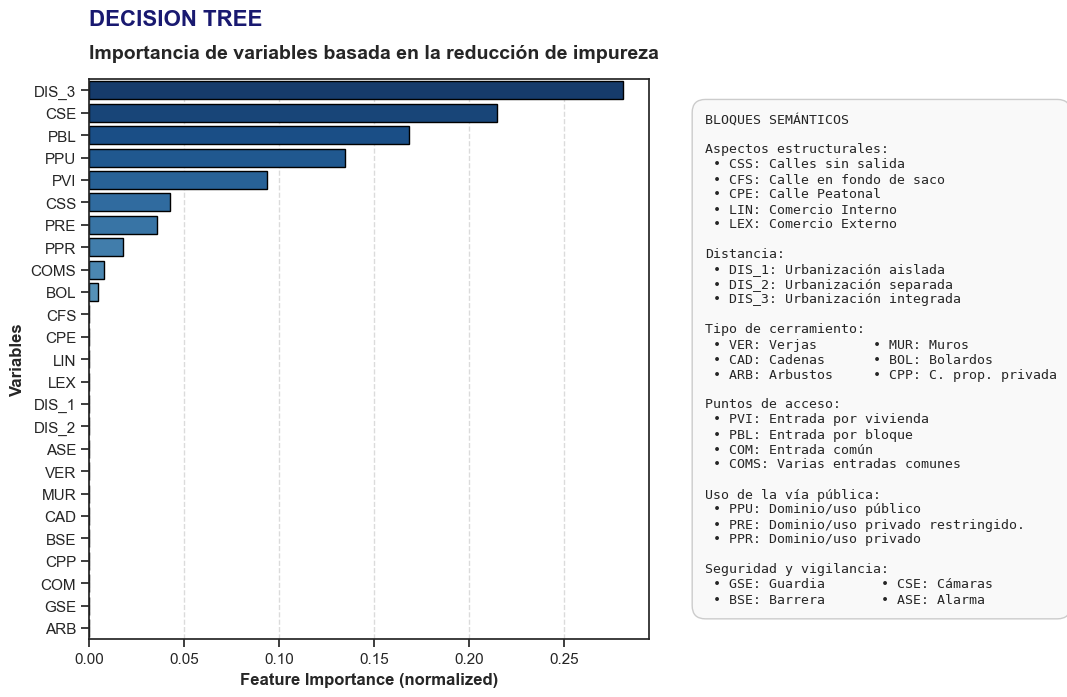

In [14]:
plot_tree_feature_importance(cfg, DT_artifact_path)

El gráfico  muestra que el árbol de decisión basa su clasificación en únicamente $10$ de las $25$ variables predictoras disponibles. Esto indica que el modelo lleva a cabo una selección implícita de características, incorporando solo aquellas variables que aportan una reducción significativa de la impureza en las particiones del espacio de características. Esta selección responde tanto al funcionamiento inherente del algoritmo como a la configuración del espacio de búsqueda de hiperparámetros, que restringe el crecimiento del árbol con el objetivo de preservar un nivel adecuado de interpretabilidad.

Las variables con mayor reducción de impureza acumulada son la *integración en el núcleo urbano (DIS_3)* y las *cámaras de seguridad (CSE)*. A nivel de bloques semánticos, destacan especialmente "*Puntos de acceso*" y `*Uso de la vía pública*''. En el primero, el árbol emplea tres de las cuatro variables disponibles, siendo la *entrada por bloque (PBL)* y la *entrada por vivienda (PVI)* las de mayor relevancia. En el segundo, las tres variables (*PPU*, *PPR* y *PRE*) participan en las particiones, aunque el *uso público de la vía (PPU)* concentra la mayor importancia. En conjunto, estos resultados muestran que el árbol fundamenta principalmente sus decisiones en cuatro dimensiones urbanísticas: la integración en el núcleo urbano, la presencia de cámaras de seguridad, el tipo de acceso y el uso de la vía pública.

Comparando este análisis de importancia de variables con el realizado para la regresión logística multinomial en la Sección correspondiente, se observa que ambos modelos coinciden en identificar como relevantes variables como *PVI*, *PBL*, *PPU* y *DIS_3*. No obstante, difieren en la importancia relativa que atribuyen a algunas de ellas. En particular, *DIS_3* constituye la característica más influyente en el árbol de decisión, mientras que en la regresión logística ocupa una posición intermedia dentro del *ranking* de importancia. De forma similar, la variable *comercios internos (LIN)*, segunda en importancia para la regresión logística, no interviene en ninguna de las particiones del árbol.

Estas discrepancias responden a la naturaleza del criterio de importancia empleado por cada modelo. Mientras que el árbol de decisión evalúa la relevancia de una característica en función de la reducción de impureza que aporta en particiones concretas del espacio de características, la regresión logística la cuantifica a partir de la magnitud de sus coeficientes dentro de un modelo lineal global. Como consecuencia, el árbol realiza una selección implícita de variables, incorporando únicamente aquellas que proporcionan una mejora significativa en algún nodo y descartando las que aportan información redundante respecto a otras ya seleccionadas. Este comportamiento favorece una representación más compacta del problema y simplifica la interpretación del modelo al basarse en un subconjunto reducido de variables.

Un ejemplo representativo de este comportamiento se observa en el bloque semántico de "*Seguridad y vigilancia*". Ambos modelos identifican este bloque como relevante para la clasificación, pero difieren en la forma de representarlo. El árbol de decisión selecciona únicamente la variable *cámaras de seguridad (CSE)*, mientras que la regresión logística incorpora conjuntamente el resto de elementos de seguridad (*ASE*, *GSE* y *BSE*), cuya contribución incrementa o reduce la probabilidad de pertenencia a los distintos grados de cerramiento. En consecuencia, el árbol de decisión basa sus reglas en la variable de seguridad con mayor capacidad discriminativa, simplificando la representación del problema. Sin embargo, esta simplificación puede limitar su capacidad para representar configuraciones menos frecuentes. Por ejemplo, un complejo residencial que no disponga de cámaras de seguridad, pero sí de otros elementos de vigilancia, podría no ajustarse al patrón aprendido por el árbol. En cambio, al incorporar simultáneamente todas las variables durante el proceso de decisión, la regresión logística ofrece una descripción más completa de este bloque semántico. Aunque ello incrementa la complejidad interpretativa del modelo, también le permite capturar patrones más sutiles, en consonancia con el mayor rendimiento observado en el *notebook* [3.2_Performance_results.ipynb](3.2_Performance_results.ipynb).

Este análisis evidencia que la elección de un mecanismo de interpretabilidad implica diferentes compromisos en la representación del problema. Mientras que el árbol de decisión proporciona una explicación más compacta basada en un subconjunto reducido de variables y reglas directas, la regresión logística ofrece una representación más detallada mediante la contribución conjunta de múltiples variables. Estas diferencias ponen de manifiesto cómo la estructura de cada modelo condiciona tanto la forma de explicar sus decisiones como su capacidad para capturar patrones complejos.

<a id="arbol_cerramiento"></a>
## 2.2 Caracterización del grado de cerramiento

Para caracterizar los patrones aprendidos por el árbol de decisión se analizan las reglas asociadas a los caminos que conectan la raíz con los nodos hoja. Estas reglas definen las condiciones que conducen a la clasificación de cada grado de cerramiento.

La siguiente figura muestra la estructura del árbol generada mediante la librería de código abierto *dtreeviz* (requiere la instalación del software *Graphviz* y su inclusión en el PATH del sistema). En los nodos internos, la distribución de las clases tras cada partición se representa mediante diagramas de barras, mientras que en los nodos hoja se emplean diagramas de sectores para mostrar la composición de las clases y el número de muestras clasificadas. Asimismo, cada hoja se identifica mediante un código numérico que facilita su referencia durante el análisis de las reglas.

> La estructura completa del árbol se ha exportado y almacenado como imagen en el directorio images/.

In [15]:
# Uncomment to update SVG file (images/viz_tree.svg)
# Graphviz software is required
#viz_tree = get_visual_decision_tree(cfg, DT_artifact_path)

<img src="../images/experiment/ARBOL_DE_DECISION_DTREEVIZ.jpg" alt="Estructura del árbol de decisión" width="90%">

Tal y como se observa en la estructura del árbol, el modelo genera un total de $15$ nodos hoja, que corresponden a las reglas empleadas para la clasificación. La longitud máxima de estas reglas es de $6$ niveles, valor fijado por la profundidad máxima del árbol. Esta restricción controla la complejidad del modelo y favorece un equilibrio adecuado entre capacidad predictiva e interpretabilidad. 

Como complemento al análisis de las reglas, la siguiente tabla recoge la distribución de clases en cada nodo hoja. Esta información permite evaluar la representatividad de cada regla mediante dos indicadores: el soporte, definido como el número total de muestras que alcanzan la hoja, y la confianza, calculada como el porcentaje de muestras pertenecientes a la clase dominante en dicho nodo.

In [16]:
leaf_df = get_leaf_classes_distribution(cfg, DT_artifact_path)

Decision_Tree model successfully loaded from pkl file.


Leaf_ID,Total_Muestras,Protegido (%),Controlado (%),Autoaislado (%),Individualista (%),Simbólico (%),Clase dominante
1,17,18.26,65.08,0.00,0.00,16.65,Controlado
2,7,0.00,24.61,0.00,75.39,0.00,Individualista
3,7,53.33,3.17,43.50,0.00,0.00,Protegido
4,33,0.00,0.00,0.00,91.08,8.92,Individualista
5,6,0.00,0.00,52.85,47.15,0.00,Autoaislado
6,14,0.00,0.00,95.88,0.00,4.12,Autoaislado
7,22,0.00,0.00,100.00,0.00,0.00,Autoaislado
8,239,4.56,81.59,0.00,0.00,13.86,Controlado
9,9,0.00,0.00,0.00,0.00,100.00,Simbólico
10,72,0.00,0.00,0.00,91.79,8.21,Individualista


A continuación, se analiza el conjunto de reglas asociado a cada grado de cerramiento. Para facilitar su identificación, cada regla se asocia al identificador del nodo hoja correspondiente, permitiendo reconstruir el camino de decisión desde la raíz del árbol hasta la hoja final y analizar la distribución de clases presentada en la tabla.

**Grado de cerramiento *Protegido***

El grado de cerramiento *Protegido* queda definido a través de dos reglas de decisión:
* **Regla ID=14:** $(DIS\_3 = 1 \land CSE = 1 \land PBL = 0) \implies \text{Protegido}$

    (Soporte: $n=67$, Confianza=$83.72\%$)
* **Regla ID=3.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PPR=1) \implies \text{Protegido}$

    (Soporte: $n=7$, Confianza=$53.33\%$)

La regla $14$ presenta la mayor confianza, ya que el $83.72\%$ de las muestras que alcanzan esta hoja pertenecen a la clase *Protegido*. Además, se trata de una regla compacta, definida únicamente por tres variables. Su interpretación semántica sugiere que los complejos residenciales protegidos suelen estar integrados en el núcleo urbano (*DIS_3*), disponer de **cámaras de seguridad (CSE)* y no presentar **entrada por bloque (PBL)*.

Por el contrario, la regla $3$ presenta una menor capacidad explicativa debido a su reducido soporte y confianza. Esta regla identifica complejos no integrados en el núcleo urbano (*DIS_3*=0), sin **calles sin salida (CSS)* ni **entrada por vivienda (PVI)*, y con **uso privado de la vía (PPR)*. Aunque el patrón es compatible con un elevado grado de cerramiento, la baja representatividad de la regla limita la generalización de esta interpretación.

En conjunto, ambas reglas muestran que el modelo relaciona la categoría *Protegido* principalmente con la presencia de elementos de seguridad y con configuraciones del espacio viario que reducen la accesibilidad externa.

**Grado de cerramiento *Controlado***

El grado de cerramiento *Controlado* se define mediante de tres reglas de decisión:
* **Regla ID=15.** $(DIS\_3 = 1 \land CSE = 1 \land PBL = 1) \implies \text{Controlado}$

    (Soporte: $n=17$, Confianza=$66.5\%$)
* **Regla ID=8.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PRE=0) \implies \text{Controlado}$

    (Soporte: $n=239$, Confianza=$81.59\%$)
* **Regla ID=1.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PPR=0 \land PBL=0) \implies \text{Controlado}$

    (Soporte: $n=17$, Confianza=$65.08\%$)

La regla $15$ describe complejos residenciales *integrados en el núcleo urbano (DIS_3)*, con presencia de *cámaras de seguridad (CSE)* y *entrada por bloque (PBL)*. Esta última variable constituye el principal elemento diferenciador respecto a la regla $14$, asociada al grado de cerramiento *Protegido*. Ambos patrones comparten la presencia de mecanismos de seguridad, siendo el punto de acceso el criterio de separación. La ausencia de *entrada por bloque* conduce a la clasificación como *Protegido*, mientras que su presencia se asocia al grado *Controlado*, matizando la intensidad de cerramiento entre ambas categorías.

La regla $8$ representa el patrón más general asociado a la categoría *Controlado*, al concentrar el mayor número de muestras clasificadas como tal. Esta regla identifica complejos *integrados en el núcleo urbano (DIS_3)* que no presentan *cámaras de seguridad (CSE)*, *entrada por vivienda (PVI)* ni *entrada por bloque (PBL)*, y que carecen de *uso público (PPU)* o *público restringido (PRE)* de la vía. Esta interpretación es similar a la caracterización obtenida mediante los coeficientes de la regresión logística, donde la ausencia de elementos de seguridad constituye uno de los principales factores asociados al grado de cerramiento *Controlado**.

Por último, la regla $1$ representa un patrón asociado a complejos residenciales *Controlados** no integrados en el núcleo urbano. Estos complejos se caracterizan por la ausencia de calles disuasorias, uso de la vía y de accesos individuales, lo que sugiere una escasa presencia de estructura viaria interna.

En conjunto, el grado de cerramiento *Controlado** puede interpretarse como una categoría asociada a complejos residenciales con una intensidad de cerramiento elevada, pero diferenciada de la categoría *Protegido** por determinados elementos que reducen dicha percepción, como la ausencia de cámaras de seguridad o la entrada por bloque.

**Grado de cerramiento *Autoaislado***

El grado de cerramiento *Autoaislado* se define a través de tres reglas de decisión:
* **Regla ID=7.** $(DIS\_3 = 0 \land CSS = 1) \implies \text{Autoaislado}$

    (Soporte: $n=22$, Confianza=$100\%$)
* **Regla ID=6.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 1) \implies \text{Autoaislado}$

    (Soporte: $n=14$, Confianza=$95.88\%$)
* **Regla ID=5.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land COMS=1) \implies \text{Autoaislado}$

    (Soporte: $n=6$, Confianza=$52.85\%$)

La variable *DIS_3*, empleada en la primera partición del árbol, resulta especialmente relevante para esta categoría, ya que aísla a todos los complejos residenciales *Autoaislados* en el lado izquierdo del árbol como se observa en la siguiente figura. Esta partición es coherente con el análisis exploratorio de la Sección de bloque de distancia, donde se identificó la ausencia de complejos residenciales *Autoaislados* integrados en el núcleo urbano.

Las reglas $7$ y $6$ presentan una elevada concentración de muestras pertenecientes a la clase *Autoaislado*, siendo la hoja $7$ un nodo puro. Ambas reglas describen configuraciones relativamente simples asociadas a complejos residenciales no integrados en el tejido urbano y con presencia de elementos relacionados con la permeabilidad del espacio viario. En la regla $7$, esta condición se refleja mediante la presencia de *calles sin salida (CSS)*, mientras que en la regla $6$ aparece asociada al *uso público de la vía (PPU)*.

Por el contrario, la regla $5$ presenta una menor capacidad discriminativa, ya que combina muestras de las categorías *Autoaislado* e *Individualista* en proporciones similares. Esta regla identifica complejos residenciales sin *calles sin salida (CSS)* ni *uso público de la vía (PPU)*, pero con presencia de accesos comunes (*COMS*). La ausencia de un patrón claramente asociado a una de las categorías limita su interpretación desde el conocimiento del dominio.

En conjunto, las reglas muestran que el grado de cerramiento *Autoaislado* se caracteriza principalmente por la falta de integración en el núcleo urbano y por la presencia de espacio viario público con calles disuasorias. Este segundo aspecto resulta especialmente relevante para diferenciar esta categoría de otros grados de cerramiento que también presentan complejos residenciales alejados del núcleo urbano. En particular, las reglas $3$ y $1$, asociadas a las categorías *Protegido* y *Controlado*, respectivamente, describen complejos residenciales no integrados en el tejido urbano, pero que no cuentan con elementos viarios disuasorios o tienen uso y dominio privado de estos espacios.

**Grado de cerramiento *Individualista***

El grado de cerramiento *Individualista* queda definido mediante cinco reglas de decisión. Las dos primeras pertenecen a la rama izquierda del árbol y, por tanto, describen complejos residenciales no integrados en el núcleo urbano $(DIS\_3 = 0)$:

* **Regla ID=2.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PPR=0 \land PBL=1) \implies \text{Individualista}$

    (Soporte: $n=7$, Confianza=$75.39\%$)
* **Regla ID=4.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=1 \land COMS=0) \implies \text{Individualista}$


    (Soporte: $n=33$, Confianza=$91.08\%$)

Ambas reglas pueden interpretarse conjuntamente, ya que el principal elemento diferenciador entre ellas es el punto de acceso. Los complejos residenciales no integrados en el núcleo urbano son clasificados como *Individualistas* cuando carecen de *uso público de la vía (PPU)* y de *calles sin salida (CSS)*, pero presentan accesos individuales mediante *entrada por bloque (PBL)* o *entrada por vivienda (PVI)*.


En la rama derecha del árbol, los complejos residenciales integrados en el núcleo urbano $(DIS\_3 = 1)$ quedan definidos mediante tres reglas adicionales:
* **Regla ID=12.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=1) \implies \text{Individualista}$
    
    (Soporte: $n=91$, Confianza=$90.35\%$)
* **Regla ID=10.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=1 \land BOL=0) \implies \text{Individualista}$
    
    (Soporte: $n=72$, Confianza=$91.79\%$)
* **Regla ID=11.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=1 \land PBL=1) \implies \text{Individualista}$
    
    (Soporte: $n=16$, Confianza=$58.04\%$)

La interpretación de estas reglas es equivalente a la observada en la rama izquierda, lo que indica que la variable *DIS_3* no constituye un criterio determinante para diferenciar esta categoría. En este caso, la clasificación vuelve a depender principalmente del punto de acceso, incorporando además la ausencia de *cámaras de seguridad (CSE)*. Así, los complejos residenciales integrados en el núcleo urbano son clasificados como *Individualistas* cuando carecen de *cámaras de seguridad (CSE)* y de *uso público de la vía (PPU)*, y presentan accesos mediante *entrada por vivienda (PVI)* o *entrada por bloque (PBL)*. Las reglas $10$ y $11$ son consecuencia de una partición poco informativa del árbol, ya que la variable *bolardos (BOL)* no modifica la clase dominante en ninguna de las dos hojas terminales.

Aunque el grado de cerramiento *Individualista* se representa mediante cinco reglas de decisión, su caracterización se fundamenta principalmente en los accesos individuales, presentes de forma recurrente en todas ellas, junto con la ausencia de distintas características que intervienen en contextos específicos del árbol. En este caso, se observa que la extracción de conocimiento basada en reglas presenta la limitación de requerir múltiples condiciones parcialmente similares para representar una misma categoría, incorporando elementos contextuales que dificultan la identificación de un patrón consistente con el conocimiento del dominio. En cambio, la representación aditiva de la regresión logística ha proporcionado una caracterización más directa y comprensible de este grado de cerramiento. Estos aspectos se discuten en profundidad en el *notebook* [5_Discussion.ipynb](5_Discussion.ipynb) donde los resultados de la evaluación de rendimiento y del estudio de interpretabilidad se analizan conjuntamente.

**Grado de cerramiento *Simbólico***

Finalmente, el grado de cerramiento *Simbólico* queda definido mediante dos reglas de decisión:
* **Regla ID=13.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 1) \implies \text{Simbólico}$

    (Soporte: $n=25$, Confianza=$100\%$)
* **Regla ID=9.**  $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PRE=1) \implies \text{Simbólico}$

    (Soporte: $n=22$, Confianza=$100\%$)

Las hojas terminales asociadas a ambas reglas son completamente puras, ya que contienen exclusivamente complejos residenciales clasificados como *Simbólico*, lo que proporciona una elevada fiabilidad interpretativa a los patrones aprendidos.

Ambas reglas comparten una misma estructura basada en la integración en el núcleo urbano (*DIS_3*=1) y la ausencia de *cámaras de seguridad (CSE)*. La diferencia entre ellas reside en la configuración del uso del espacio viario: la regla $13$, que concentra el mayor número de muestras, identifica complejos con *uso público de la vía (PPU)*, mientras que la regla $9$ representa complejos con *uso público restringido (PRE)* siempre que no presenten accesos por *vivienda (PVI)* ni por *bloque (PBL)*. Desde una perspectiva urbanística, ambos patrones reflejan configuraciones con una baja intensidad de cerramiento, coherente con la naturaleza de la categoría *Simbólico*.

<a id="caja_negra"></a>
# 3. Modelos de caja negra

La interpretabilidad de los modelos *SVM*, *Random Forest* y *XGBoost* se aborda mediante la técnica de explicabilidad *post-hoc* *SHAP*. Los valores *SHAP* obtenidos para cada modelo se almacenan como *arrays* de *NumPy* en archivos con extensión *.npy* ubicados en el directorio *output/SHAP_global* del repositorio.

Las contribuciones *SHAP* se analizan de forma agregada para estudiar la importancia global de las variables y de forma desagregada para caracterizar los distintos grados de cerramiento.

<a id="caja_negra_glob"></a>
## 3.1 Importancia global de variables

La aplicación de *SHAP* produce un valor para cada combinación de observación, variable predictora y clase, que cuantifica la contribución de dicha variable a que un complejo residencial sea clasificado por el modelo en un determinado grado de cerramiento.

Para obtener una medida global de la importancia de cada variable se calcula el promedio del valor absoluto de sus contribuciones *SHAP* considerando conjuntamente todas las observaciones y clases (*mean absolute SHAP value*). El uso del valor absoluto permite cuantificar la influencia global de una variable sobre las predicciones del modelo, independientemente de que su efecto incremente o reduzca la salida del modelo hacia un determinado grado de cerramiento. Este criterio es análogo al empleado en la regresión logística, donde la importancia global se ha estimado mediante el promedio del valor absoluto de los coeficientes asociados a cada variable. La siguiente figura muestra la importancia global de las variables obtenida mediante esta agregación para los modelos de caja negra.

In [17]:
# Set path to model PKL files
SVM_artifact_path =  os.path.join(models_folder, "SVM_model.pkl")
RF_artifact_path =  os.path.join(models_folder, "Random_Forest_model.pkl")
XG_artifact_path =  os.path.join(models_folder, "XGBoost_model.pkl")

In [18]:
#################
# SVM
#################

# Uncomment to recalculate shap values for SVM 

#shap_values_SVM = get_shap_svm(cfg, SVM_artifact_path)

# The values has been stored in output/SHAP_global/SVM_shap_global.npy to avoid SHAP calculation time (approx 20 minutes)
shap_values_SVM = np.load("../output/SHAP_global/SVM_shap_global.npy")

In [19]:
#################
# Random Forest
#################
shap_values_RF = get_shap_tree(cfg, RF_artifact_path)

Random_Forest model successfully loaded from pkl file.
Get shap values with KernelExplainer...
Shap values calculated succesfully.
Array size: (642, 25, 5)

Saving results...
Output directory: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\output\SHAP_global


In [20]:
#################
# XGBoost
#################
shap_values_XG = get_shap_tree(cfg, XG_artifact_path)

XGBoost model successfully loaded from pkl file.
Get shap values with KernelExplainer...
Shap values calculated succesfully.
Array size: (642, 25, 5)

Saving results...
Output directory: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\output\SHAP_global


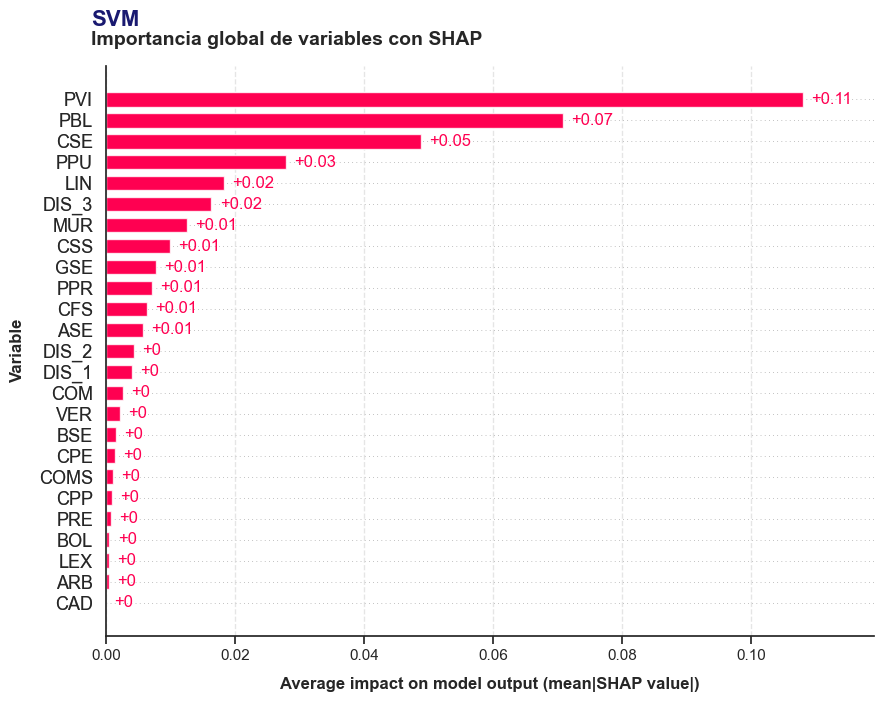

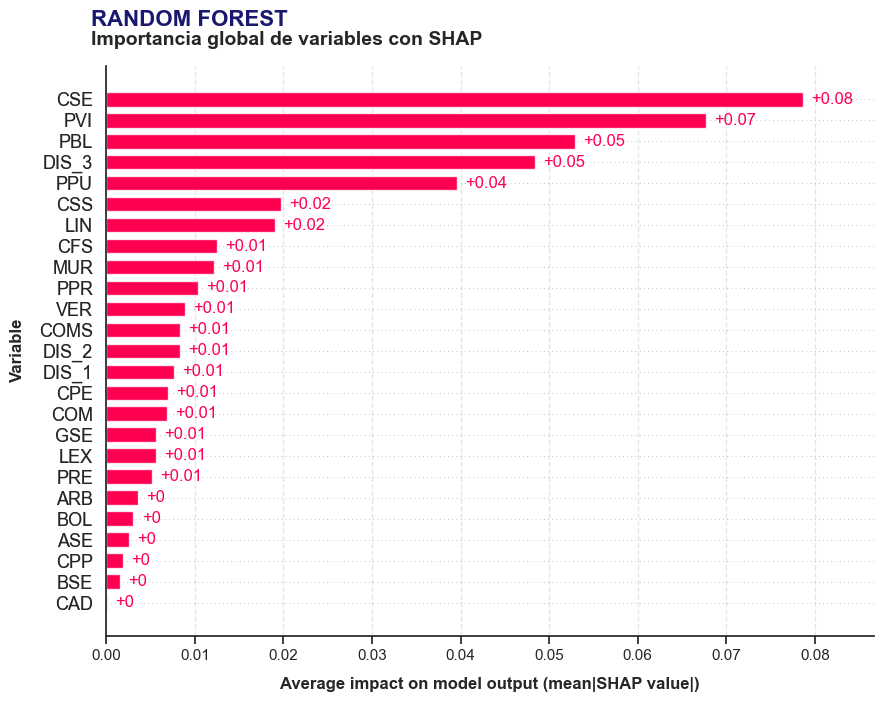

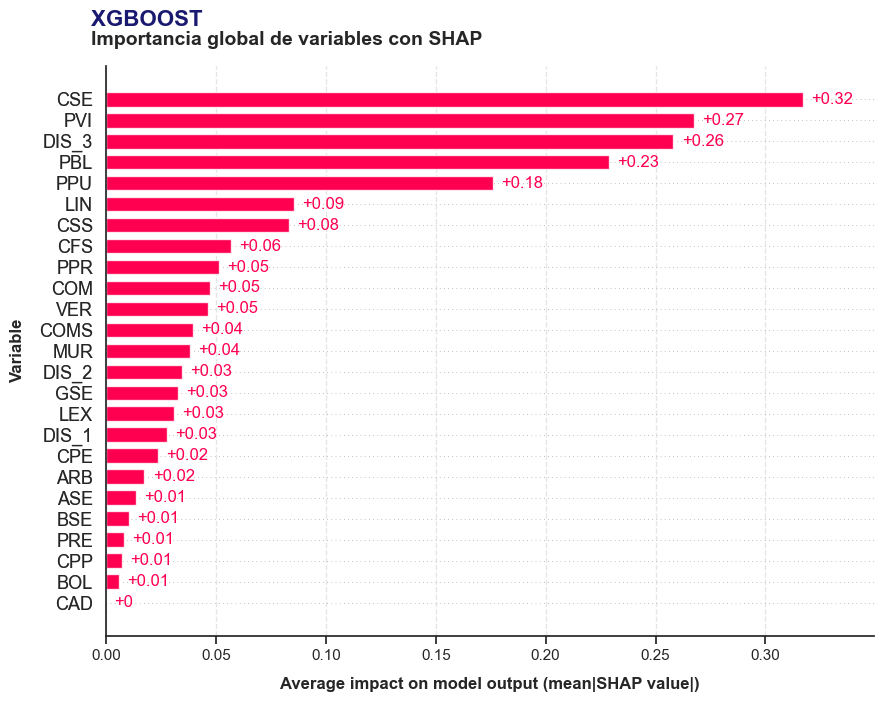

In [21]:
plot_shap_global_feature_importance(cfg, shap_values_SVM, model_name="SVM", num_features_display=25, figsize=[9,7])
plot_shap_global_feature_importance(cfg, shap_values_RF, model_name="Random Forest", num_features_display=25, figsize=[9,7])
plot_shap_global_feature_importance(cfg, shap_values_XG, model_name="XGBoost", num_features_display=25, figsize=[9,7])

Los gráficos de importancia de variables muestran una elevada consistencia entre los tres modelos de caja negra. A pesar de sus diferencias en la arquitectura interna y en el mecanismo de aprendizaje, *SVM*, *Random Forest* y *XGBoost* identifican las variables *CSE*, *PVI*, *PBL* y *PPU* como las de mayor influencia, con variaciones en su orden de importancia. Esta convergencia sugiere que los principales factores urbanísticos que determinan el grado de cerramiento son estables y su relevancia puede interpretarse como un patrón estructural del conjunto de datos, más que como un artefacto derivado del sesgo inductivo o de las características de un algoritmo particular.

La principal diferencia entre los modelos reside en la distribución de la importancia a partir de la quinta variable más relevante. En los modelos *SVM* y *Random Forest*, los valores *SHAP* decrecen de forma abrupta, convergiendo rápidamente hacia contribuciones próximas a cero. En cambio, *XGBoost* presenta una disminución mucho más gradual, manteniendo un mayor número de variables con contribuciones relevantes.

Este comportamiento puede explicarse por la naturaleza secuencial del algoritmo *Gradient Boosting*, en la que cada árbol se entrena para corregir los errores residuales del conjunto de árboles previamente construidos. En las primeras iteraciones, el algoritmo explota las variables que proporcionan la mayor reducción de la función de pérdida. A medida que disminuye la capacidad de mejora de estas variables, los árboles posteriores recurren a variables "secundarias", cuya contribución inicial era menor, pero que permiten modelar relaciones más sutiles presentes en los residuos. Este fenómeno puede relacionarse con los resultados del *notebook* [3.2_Performance_results.ipynb](3.2_Performance_results.ipynb), donde *XGBoost* obtiene el mejor rendimiento predictivo del experimento.

La consistencia observada no se limita a los modelos de caja negra. El conjunto de variables dominantes es consistente con el identificado en los modelos transparentes mediante sus mecanismos de interpretabilidad intrínseca, lo que refuerza la robustez de los patrones extraídos. La siguiente tabla  recoge las cinco variables más importantes en cada modelo de acuerdo con la medida de importancia utilizada en cada uno de ellos.

| Posición | Regresión Logística (Coeficientes) | Árbol de Decisión (Impureza) | SVM (SHAP Global) | Random Forest (SHAP Global) | XGBoost (SHAP Global) |
| :---: | :--- | :--- | :--- | :--- | :--- |
| **1º** | PPU | DIS_3 | PVI | CSE | CSE |
| **2º** | LIN | CSE | PBL | PVI | PVI |
| **3º** | PVI | PBL | CSE | PBL | DIS_3 |
| **4º** | PBL | PPU | PPU | DIS_3 | PBL |
| **5º** | CSE | PVI | LIN | PPU | PPU |

Como puede observarse, las variables *PPU*, *PVI*, *PBL* y *CSE* aparecen de forma consistente entre las cinco variables más importantes. Las diferencias se encuentran en la *integración en el núcleo urbano (DIS_3)* que aparece en los modelos basados en árboles (árbol de decisión, *Random Forest* y *XGBoost*), y los *comercios internos (LIN)* que aparece en la regresión logística y *SVM*. La relevancia de *DIS_3* en los modelos basados en árboles resulta coherente con su elevada capacidad discriminativa, ya que permite separar de forma clara los complejos residenciales *Autoaislados*, tal y como se ha identificado tanto en el [análisis exploratorio](1_EDA.ipynb) como en el estudio de interpretabilidad de este *notebook*. Mientras que la importancia de *LIN*, en los modelos basados en funciones de decisión global, sugiere que esta variable puede aportar información complementaria en combinación con otras características, aunque no presente suficiente capacidad discriminativa individual.

Esta elevada consistencia entre las variables más influyentes en los modelos de caja negra y transparentes indica que los algoritmos de mayor complejidad se basan en los mismos pilares conceptuales que los modelos transparentes. Su ventaja predictiva no parece derivar de la utilización de variables diferentes, sino de una modelización más compleja para capturar relaciones no lineales e interacciones entre dichas variables. Este resultado muestra que *SHAP* proporciona a los modelos de caja negra una interpretabilidad coherente con la obtenida mediante los mecanismos intrínsecos de los modelos transparentes. Aunque no permite inspeccionar directamente la estructura interna del modelo, sí identifica los principales factores que condicionan sus predicciones mediante una representación basada en contribuciones individuales y aditivas, conceptualmente equivalente a la interpretación de los coeficientes de la regresión logística multinomial.

Tras analizar la importancia de las variables en los diferentes modelos puede concluirse que la clasificación del grado de cerramiento está principalmente determinada por cuatro dimensiones semánticas de la morfología urbana: los servicios de seguridad, la integración en el núcleo urbano, la forma de acceso y el tipo de uso de la vía. Las variables del bloque "*Aspectos estructurales*'" presentan una importancia intermedia, destacando los *comercios internos (LIN)* y las *calles sin salida (CSS)*. Por el contrario, el bloque de "*tipos de cerramiento*'" es el que menor impacto tiene en todos los modelos. Únicamente en *XGBoost* se observa una contribución no despreciable de elementos como los *muros (MUR)* y las *verjas (VER)*, aunque su relevancia sigue siendo reducida en comparación con el resto de variables. Este comportamiento muestra la capacidad de *XGBoost* para capturar patrones más complejos, incorporando información de variables que en otros modelos tienen un papel prácticamente residual.

<a id="caja_negra_cerramiento"></a>
## 3.2 Caracterización del grado de cerramiento

La caracterización de los grados de cerramiento se realiza sobre el modelo *XGBoost*. El análisis de importancia global de variables ha mostrado que los tres modelos de caja negra presentan un comportamiento consistente, identificando un núcleo común de variables relevantes. Los tres modelos comparten el mismo mecanismo de interpretabilidad basado en valores *SHAP*, por lo que realizar el análisis detallado sobre cada modelo aportaría información redundante. Por este motivo, se selecciona *XGBoost* como representante de esta familia de algoritmos, al ser el modelo de caja negra con mayor rendimiento predictivo y la principal alternativa a los modelos transparentes.

Para realizar este estudio a través de los valores *SHAP* se emplean dos visualizaciones complementarias:

* **Gráfico de barras de importancia por clase.** Representa, para cada grado de cerramiento, la importancia global de las variables predictoras mediante la media de los valores absolutos *SHAP* obtenidos en todas las observaciones, mediante un gráfico de barras como los mostrados en la siguiente figura.

* **Gráfico de densidad (*Beeswarm plot*).** Esta visualización representa la distribución de los valores *SHAP* de cada variable predictora para una clase determinada, permitiendo caracterizar no solo la magnitud y dirección de su contribución a la predicción, sino también la variabilidad de dicho efecto entre las distintas observaciones.

  Cada punto representa una observación individual, cuya posición horizontal indica la magnitud y dirección de la contribución *SHAP*.

  Los valores positivos indican que la variable desplaza la predicción hacia la pertenencia al grado de cerramiento analizado, mientras que los valores negativos indican el efecto opuesto. La dispersión horizontal de los puntos permite evaluar la variabilidad del efecto de una característica entre observaciones, identificando si su contribución es consistente o depende del contexto del complejo residencial. Además, el color de los puntos codifica el valor original de la variable predictora. Dado que las características empleadas son binarias, el color azul representa la ausencia de la característica, mientras que el rojo representa su presencia. Esta codificación permite interpretar qué configuraciones urbanísticas actúan como factores catalizadores o inhibidores de cada grado de cerramiento, de forma análoga al análisis realizado mediante los coeficientes de la regresión logística multinomial.

A continuación se analiza la interpretabilidad de cada grado de cerramiento.

**Grado de cerramiento *Protegido***

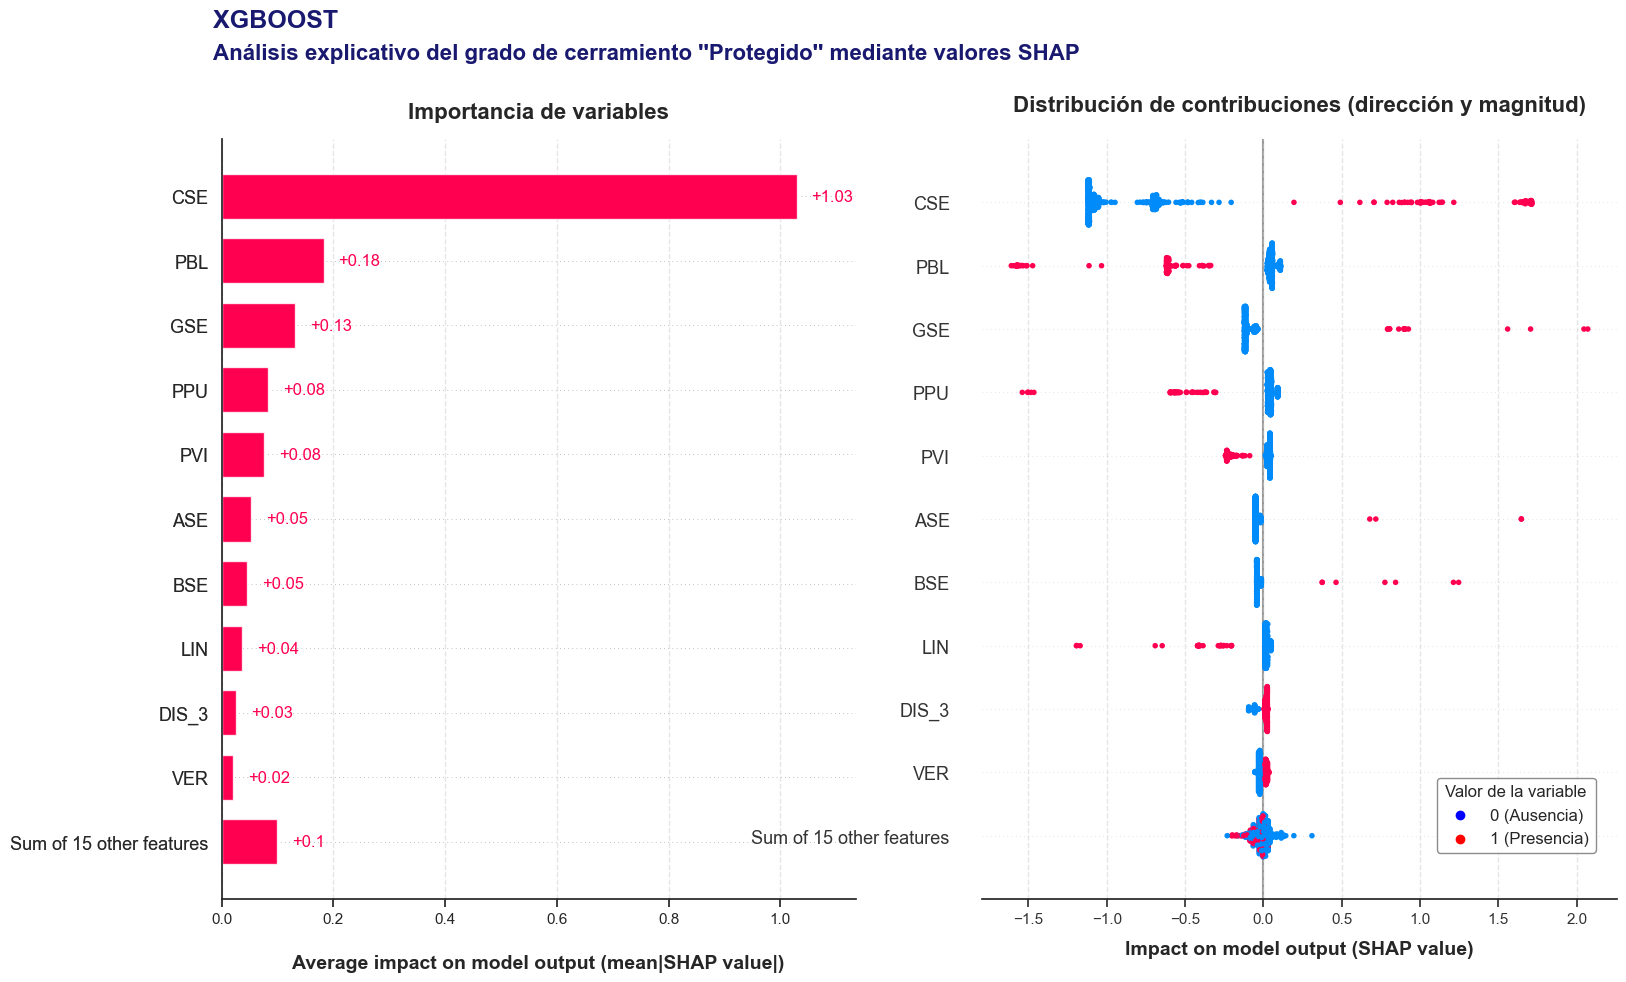

In [22]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Protegido", model_name="XGBoost", num_features_display=11)

En el grado de cerramiento *Protegido*, la variable con mayor impacto promedio sobre las predicciones del modelo es las *cámaras de seguridad (CSE)*. Sobre el gráfico de densidad se identifica que la presencia de cámaras de seguridad actúa como un claro catalizador para la asignación de esta categoría, mientras que su ausencia reduce drásticamente la contribución de pertenecer a ella. El resto de servicios de seguridad (*ASE*, *BSE* y *GSE*) exhiben un comportamiento asimétrico: presentan valores *SHAP* elevados y positivos cuando están presentes en el complejo residencial, pero su ausencia no penaliza la contribución a este grado de cerramiento de forma tan marcada como *CSE*.

Este comportamiento es coherente con el [análisis exploratorio](1_EDA.ipynb), donde se ha identificado que las *cámaras de seguridad (CSE)* constituyen el elemento más frecuente del bloque de ``*seguridad y vigilancia*'' dentro de los complejos residenciales *Protegidos*, con una presencia notablemente superior al resto de servicios. El modelo *XGBoost* ha capturado este patrón, de modo que la presencia de cualquier servicio de seguridad contribuye positivamente hacia la clase *Protegido*, pero únicamente la ausencia de cámaras de seguridad funciona como un factor inhibidor crítico.

Más allá de las variables asociadas a los servicios de seguridad, la presencia de *comercios internos (LIN)*, el *uso público de la vía (PPU)* y la *entrada por bloque (PBL)* muestran las principales contribuciones negativas hacia la clase *Protegido*.

En conjunto, la caracterización de este grado de cerramiento muestra una tipología con baja permeabilidad al tránsito de personas no residentes, definida por la presencia de mecanismos de seguridad y vigilancia orientados a controlar el acceso a los espacios comunes. Este patrón es consistente con la caracterización resultada tanto en el modelo de regresión logística como en el árbol de decisión.

**Grado de cerramiento *Controlado***

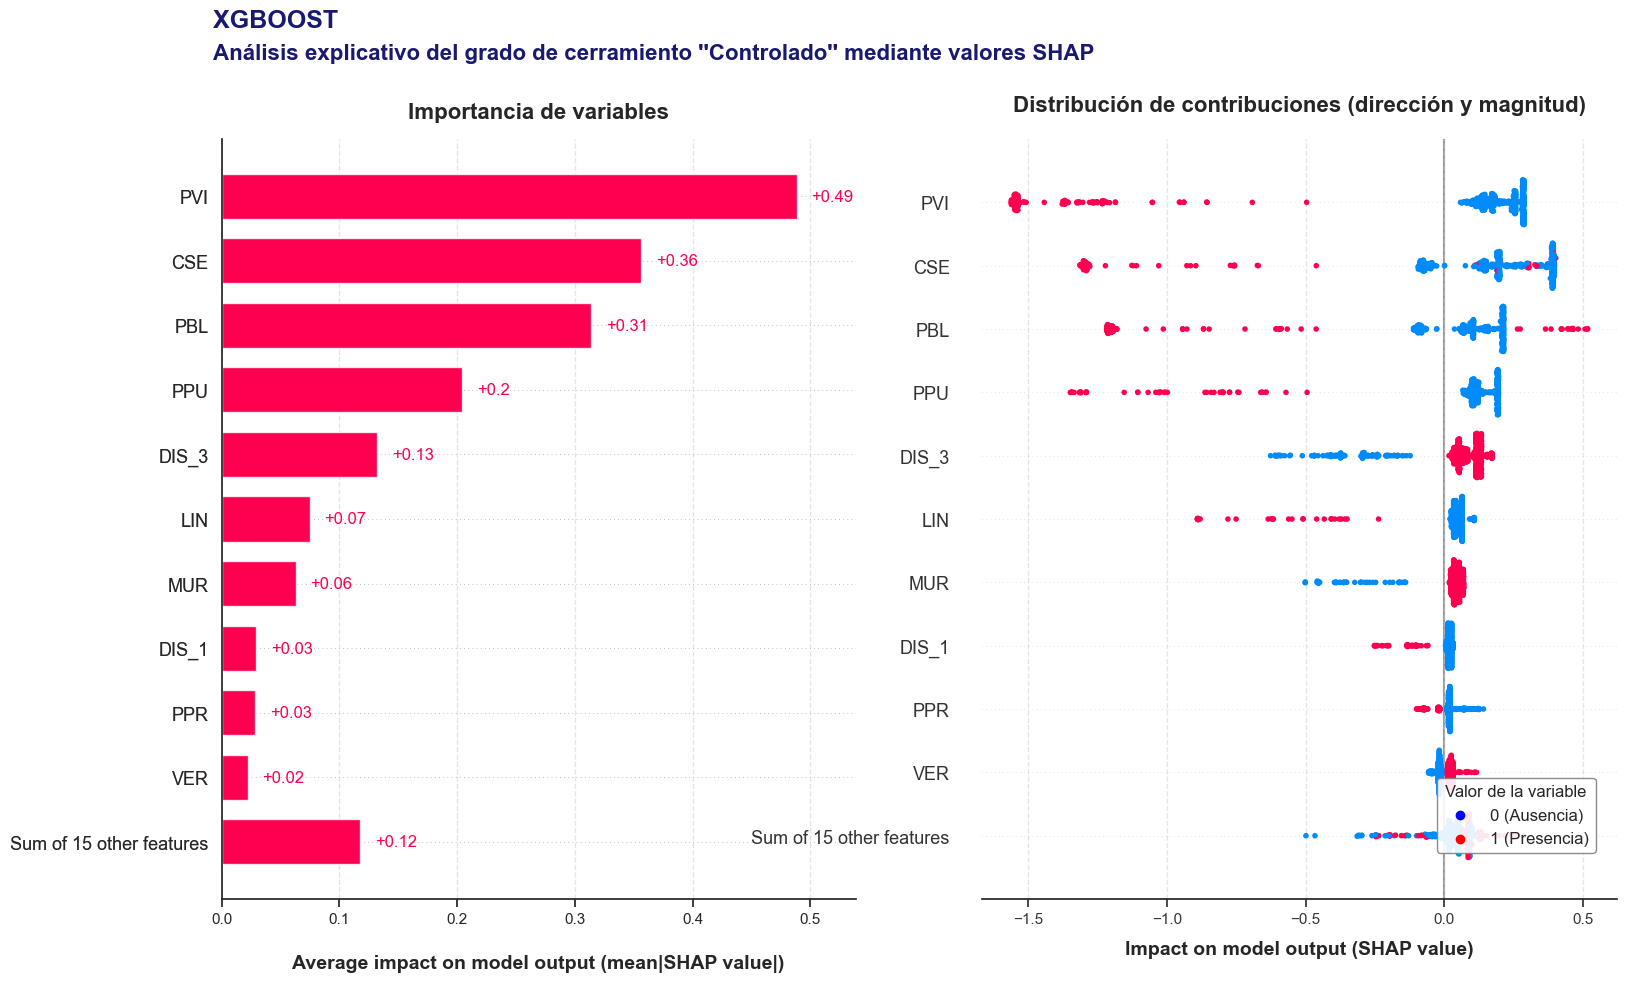

In [23]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Controlado", model_name="XGBoost", num_features_display=11)

En el grado de cerramiento *Controlado*, las variables con mayor contribución media a las predicciones del modelo son las *cámaras de seguridad (CSE)*, la *entrada por bloque (PBL)*, la *entrada por vivienda (PVI)* y el *uso público de la vía (PPU)*. El gráfico de densidad muestra que la presencia de estas características presenta contribuciones *SHAP* predominantemente negativas para esta categoría, comportándose como elementos inhibidores de la pertenencia al grado de cerramiento *Controlado*.

De este modo, el análisis mediante *SHAP* proporciona una interpretación conceptualmente equivalente a la obtenida a partir de los coeficientes del modelo de regresión logística. El grado de cerramiento *Controlado* comparte con *Protegido* una baja presencia de elementos asociados a la permeabilidad del complejo residencial, reflejada en la ausencia de *uso público de la vía (PPU)* y de *comercios internos (LIN)*, pero se diferencia a través de la ausencia de *cámaras de seguridad (CSE)*. En este caso, la interpretabilidad se ve enriquecida por la elevada contribución negativa asociada a las entradas por *vivienda (PVI)* y por *bloque (PBL)* que aporta información adicional para diferenciar esta categoría del grado de cerramiento *Individualista*.

No obstante, se observa una ligera dispersión de valores *SHAP* positivos en la presencia de las variables *CSE* y *PBL*, contribuyendo moderadamente a la predicción de esta categoría. Este comportamiento muestra que la contribución de estas variables no es completamente homogénea, sino que puede depender de la combinación con otras características del complejo residencial. Por tanto, aunque ambas variables actúan predominantemente como elementos inhibidores para el grado de cerramiento *Controlado*, el modelo captura configuraciones particulares en las que su efecto se modifica mediante la interacción con otras variables. Esto pone de manifiesto una de las principales ventajas de *SHAP* frente a los mecanismos intrínsecos de los modelos transparentes, ya que permite descomponer la predicción a nivel de instancia y analizar cómo varía la contribución de una variable entre diferentes observaciones. Esta capacidad contrasta con la interpretación mediante los coeficientes de la regresión logística, donde cada característica está asociada a un único valor global que representa su efecto dentro de la estructura lineal del modelo.

**Grado de cerramiento *Autoaislado***

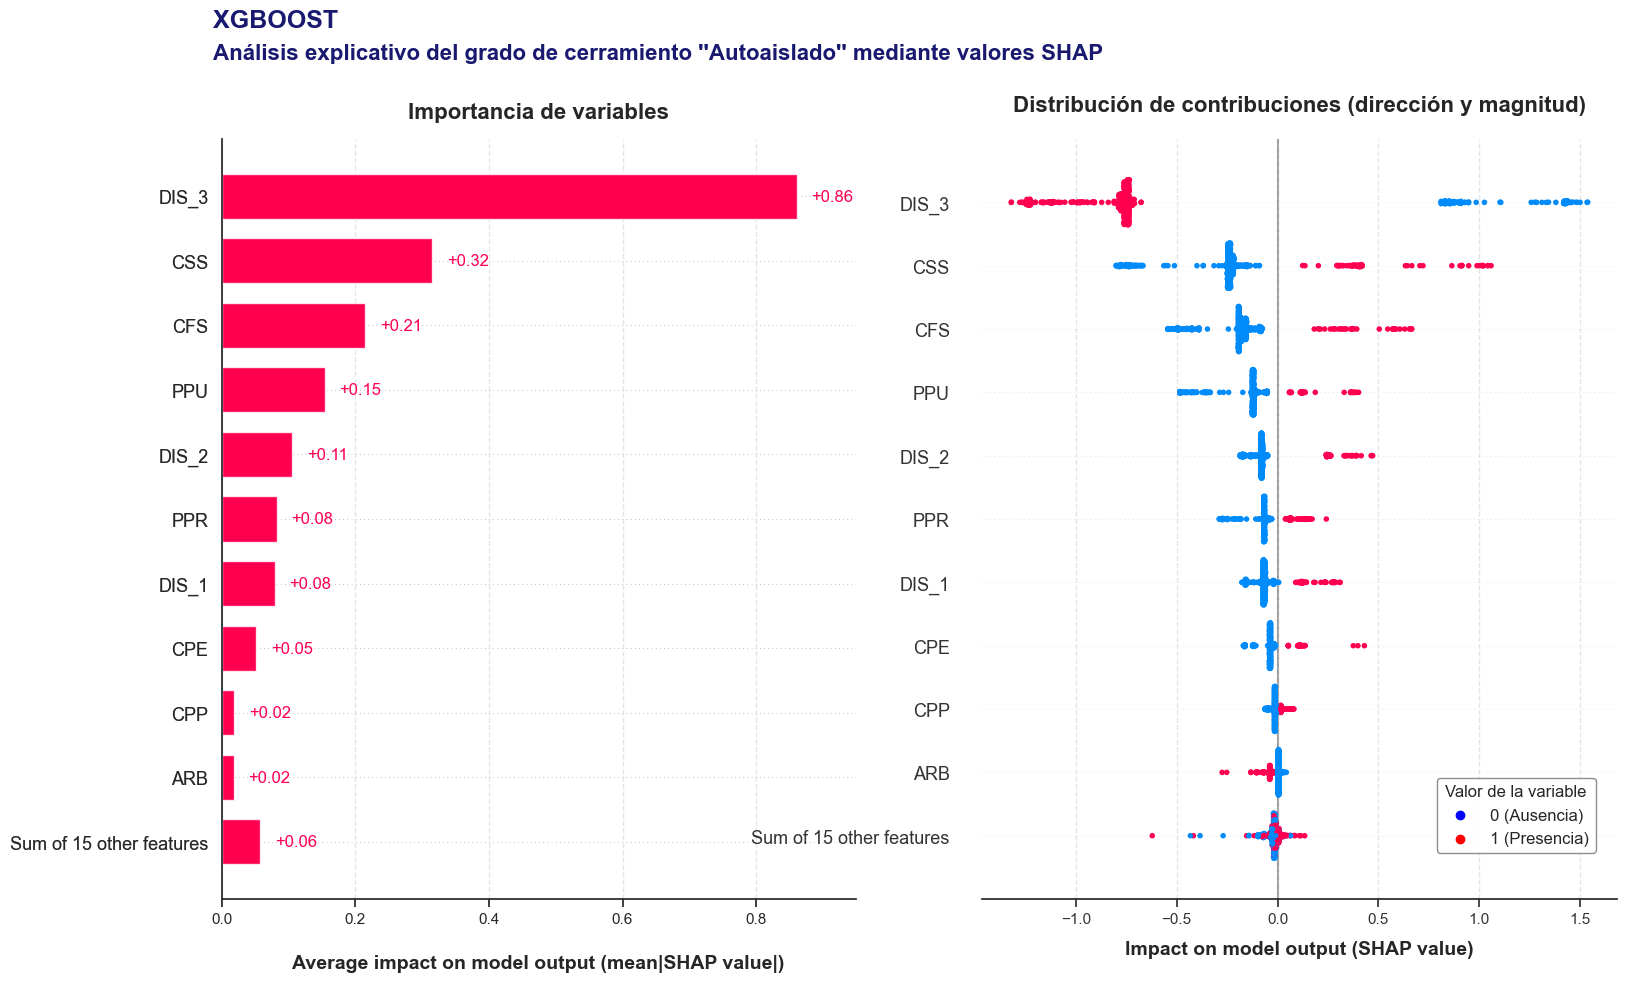

In [24]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Autoaislado", model_name="XGBoost", num_features_display=11)

En el gráfico  se observa que la variable más influyente en este grado de cerramiento es la *integración en el núcleo urbano (DIS_3)* cuya presencia reduce la salida del modelo hacia esta categoría y su ausencia la aumenta en magnitudes similares. Por otro lado, existe un grupo de variables asociado a las calles disuasorias (*CSS* y *CFS*) y al dominio y uso de la vía (*PPU* y *PPR*) cuya presencia actúa como factor catalizador y su ausencia como factor inhibidor.

En conjunto, la caracterización de este grado de cerramiento es equivalente a la que se ha obtenido con los modelos transparentes, especialmente con la regresión logística.

**Grado de cerramiento *Individualista***

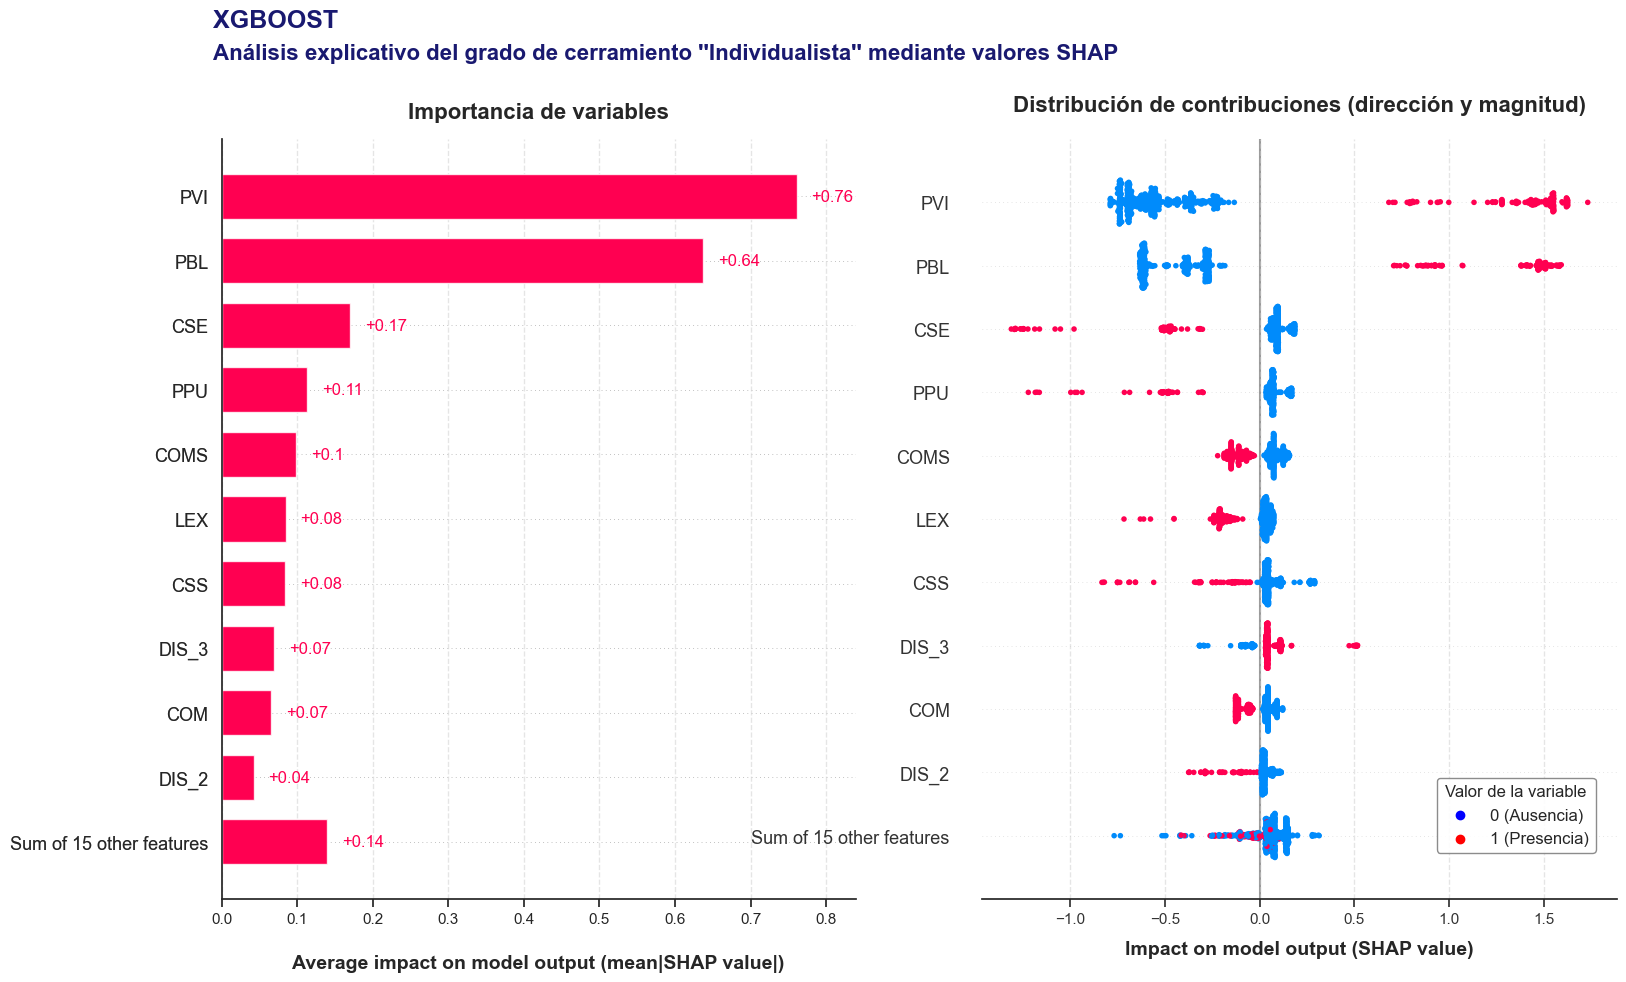

In [25]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Individualista", model_name="XGBoost", num_features_display=11)

En el gráfico se identifica que las variables con mayor impacto en la salida del modelo son la entrada por vivienda (*PVI*) y por bloque (*PBL*), cuya presencia actúa como factor catalizador y su ausencia como inhibidor. Por otro lado, la presencia de cámaras de seguridad (*CSE*) y el uso público de la vía (*PPU*) alcanzan valores SHAP notablemente negativos por lo que reducen la contribución para que un complejo residencial sea clasificado como *Individualista*.

A partir de este análisis, esta categoría queda esencialmente definida por la presencia de accesos individuales a las zonas comunes que no están controlados mediante mecanismos o servicios de seguridad. Esta caracterización se asemeja a la obtenida mediante el modelo de regresión logística y destaca por proporcionar una interpretación más directa y comprensible de este grado de cerramiento que la obtenida mediante el árbol de decisión.

**Grado de cerramiento *Simbólico***

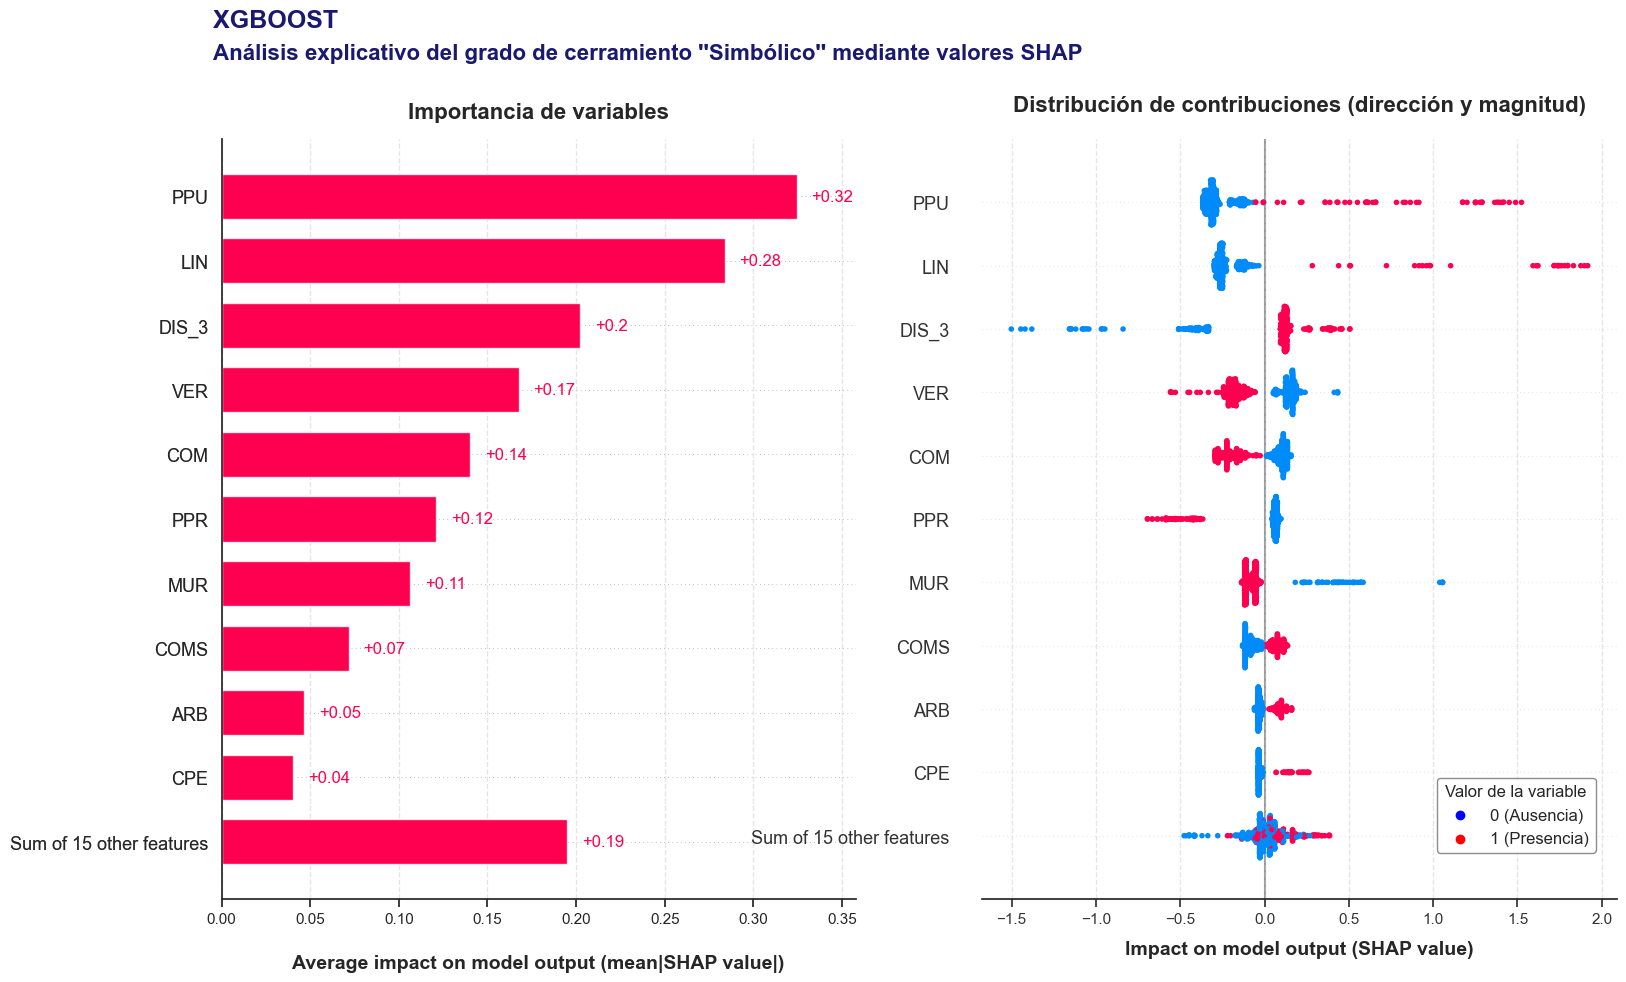

In [27]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Simbólico", model_name="XGBoost", num_features_display=11)

A diferencia de las categorías anteriores, en el grado de cerramiento *Simbólico* no se identifica una variable con una contribución claramente dominante sobre el resto. Como se observa en el gráfico, varias características presentan valores *SHAP* de magnitud moderada y similar, lo que refleja un patrón de clasificación más distribuido entre múltiples variables. Este comportamiento es coherente con la naturaleza de esta categoría, que representa el grado de cerramiento más sutil y, por tanto, presenta una mayor dificultad para ser diferenciada por el modelo.

De acuerdo al gráfico de densidad, las contribuciones positivas más altas se alcanzan con la presencia de *comercios interiores (LIN)* y el *uso público de la vía (PPU)*. Ambas características representan elementos urbanos que favorecen una mayor permeabilidad del espacio residencial, lo que reduce la intensidad de cerramiento. En contraposición, se observa cómo el *uso y dominio privado de la vía (PPR)* reduce la contribución a esta clase. La variable que produce las contribuciones negativas de mayor magnitud es la ausencia de *integración en el núcleo urbano* (*DIS_3*=0). Este comportamiento indica que los complejos residenciales situados fuera del núcleo urbano presentan configuraciones que el modelo asocia con intensidades de cerramiento más elevadas, alejándolos de la categoría *Simbólico*.

En este grado de cerramiento, las variables del bloque "*Tipos de cerramiento*'", como las *verjas (VER)* y los *muros (MUR)*, presentan una contribución relevante en la predicción del modelo. La presencia de *verjas (VER)* genera contribuciones negativas hacia la clase *Simbólico*, mientras que la ausencia de *muros (MUR)* favorece su predicción. Este comportamiento indica que la existencia de elementos de cerramiento físico de tipo `duro'' constituye un patrón poco compatible con esta categoría.

Puede concluirse que el grado de cerramiento *Simbólico* presenta una caracterización distribuida entre múltiples elementos urbanísticos, sin que una única variable domine la predicción del modelo. En este sentido, destacan especialmente el *uso público de la vía (PPU)*, la presencia de *comercios internos (LIN)* y la *integración en el núcleo urbano (DIS_3)*, cuya combinación define un patrón asociado a una baja intensidad de cerramiento.

La interpretabilidad obtenida mediante *SHAP* para este grado de cerramiento proporciona información de mayor interés para el conocimiento del dominio que la extraída mediante los modelos transparentes. Esta diferencia puede atribuirse a la capacidad de *XGBoost* para capturar relaciones no lineales y combinar la contribución de un mayor número de variables, lo que permite una caracterización más rica de los patrones asociados a esta categoría. Además, su mayor rendimiento predictivo en este grado de cerramiento favorece la obtención de explicaciones más representativas, al estar basadas en un mayor número de predicciones correctamente clasificadas por el modelo.